# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [4]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['Hp'] = '#63D15Aff'
    genotype_color['ArchT'] = '#FF9BD6ff'
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['wt'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
"#7b62c5ff"
'#1F2A63'
'#C276A5'

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [5]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260108.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20251220.csv


## Main

### Visualize the cheeseboard maze task variables

In [7]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [287]:
dl.id, dl.ses_dir

('A', 'ses-07_date-20241211')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

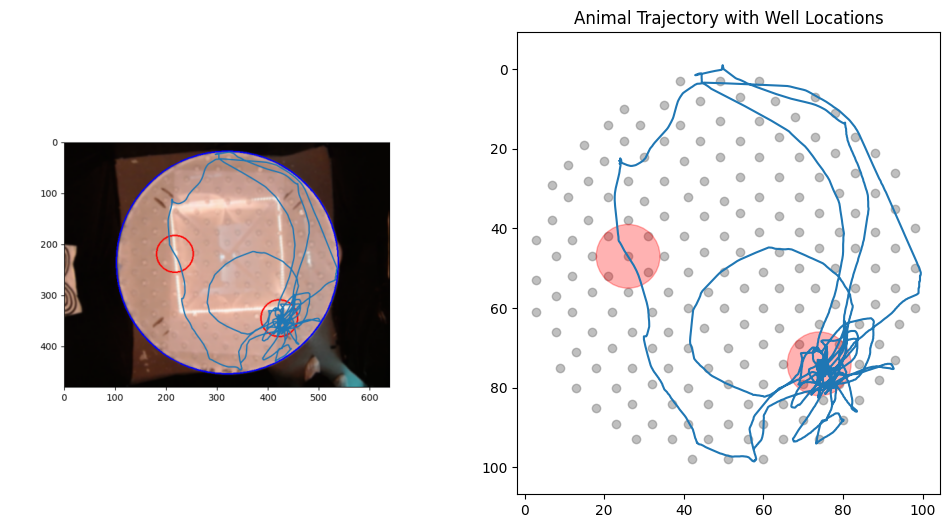

In [288]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [6]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [8]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


### Compute the time animal took to reach the trigger zone

In [290]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5141,63,BR,20251223,8,5,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5142,63,BR,20251223,8,6,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5143,63,BR,20251223,8,7,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5144,63,BR,20251223,8,8,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN


In [232]:
#  compute distance to first trigger entry for all trials
#  (optionally require first visit duration >= 2000 ms)

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata['dist_to_trigger'] = np.nan

R_TRIGGER = (10/1.2)

# --- SETTINGS you can comment/uncomment ---
REQUIRE_STAY_2S = True          # <- set False for "any entry"
MIN_DUR_MS = 2000               # duration threshold in ms (per your df_trig duration units)
# -----------------------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    pos = add_distance_travelled(position)
    if pos is None or len(pos) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    pos_ = add_dist_to_trigger(pos, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i+1)
        if df_trig is None or len(df_trig) == 0:
            continue
        df_trig['trigger_id'] = i + 1
        dfs.append(df_trig)

    # if never entered any reward zone at all, use full-trial distance
    if len(dfs) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = pos_['cum_dist'].iloc[-1]
        continue

    df_all = pd.concat(dfs, ignore_index=True).sort_values('t_enter').reset_index(drop=True)

    # ------------------------------------------------------------
    # OPTIONAL: require the FIRST visit where duration >= 2000 ms
    # ------------------------------------------------------------
    if REQUIRE_STAY_2S:
        df_use = df_all[df_all['duration'] >= MIN_DUR_MS].copy()
        # If no "stay" visits, decide what you want:
        # Option A: set distance to full-trial distance (like "never learned")
        if len(df_use) == 0:
            metadata.at[trial_id, 'dist_to_trigger'] = pos_['cum_dist'].iloc[-1]
            continue
        # Option B (alternative): set NaN instead
        # if len(df_use) == 0:
        #     metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        #     continue
    else:
        df_use = df_all

    # time of first qualifying entry to ANY trigger
    t_enter_first = df_use.iloc[0]['t_enter']

    # distance travelled up to that time (last sample with t <= t_enter_first)
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    dist_to_trigger = 0.0 if len(idxs) == 0 else pos_['cum_dist'].iloc[idxs[-1]]

    metadata.at[trial_id, 'dist_to_trigger'] = dist_to_trigger

metadata[['sub','ses','trial_type','trial_type_day','dist_to_trigger']].head()

  0%|          | 0/4611 [00:00<?, ?it/s]

 15%|█▌        | 713/4611 [00:07<00:39, 99.79it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1184/4611 [00:13<00:34, 99.29it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2611/4611 [00:25<00:13, 152.73it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:43<00:00, 107.16it/s]


,sub,ses,trial_type,trial_type_day,dist_to_trigger
0,1,1,H,1,919.947051
1,1,1,H,1,215.035375
2,1,1,H,1,166.399759
3,1,1,H,1,7.878806
4,1,1,H,1,476.763613


  genotype  total_trial_n    mean_dist     sd_dist   n
0     ChR2              1  1134.618476  913.694376  12
1     ChR2              2  1048.476847  887.601684  12
2     ChR2              3  1073.876284  831.763330  12
3     ChR2              4   653.919662  589.351233  12
4     ChR2              5   996.680091  950.793711  12


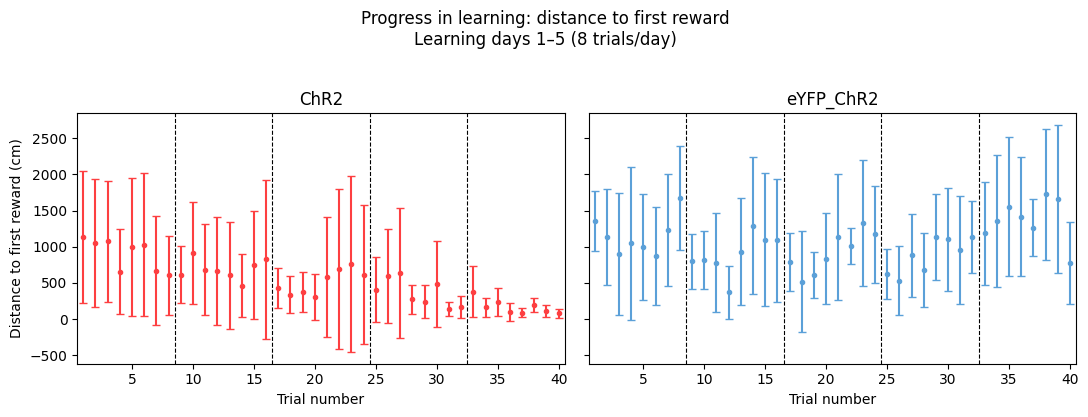

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Filter: usable, not short, ChR2/eYFP, LEARNING (L) days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].between(1, 5)) &
    (metadata['dist_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Ensure we have trial_in_day = 1..8
# ------------------------------------------------------------
trials_per_day = 8

candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    # fall back: order within session for each animal
    meta_L = meta_L.sort_values(['sub', 'ses', 'trial_type_day']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, trials_per_day)].copy()

# ------------------------------------------------------------
# 3) Create global trial index = "total_trial_n" (1..40 for 5 days)
# ------------------------------------------------------------
meta_L['total_trial_n'] = (
    (meta_L['trial_type_day'] - 1) * trials_per_day + meta_L['trial_in_day']
).astype(int)

# ------------------------------------------------------------
# 4) Group: mean & SD distance per genotype × total_trial_n
# ------------------------------------------------------------
summary = (
    meta_L
    .groupby(['genotype', 'total_trial_n'])['dist_to_trigger']
    .agg(mean_dist='mean', sd_dist='std', n='size')
    .reset_index()
)

print(summary.head())

# ------------------------------------------------------------
# 5) Plot: error bars (mean ± SD) per trial, faceted by group
# ------------------------------------------------------------
groups = ['ChR2', 'eYFP_ChR2']
colors = {g: get_genotype_color(g) for g in groups}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, g in zip(axes, groups):
    df_g = summary[summary['genotype'] == g].sort_values('total_trial_n')

    x = df_g['total_trial_n'].values
    y = df_g['mean_dist'].values
    sd = df_g['sd_dist'].values

    # vertical error bars only (like your R code)
    ax.errorbar(
        x, y,
        yerr=sd,
        fmt='none',
        ecolor=colors[g],
        elinewidth=1.5,
        capsize=3
    )

    # optional: mean points
    ax.plot(x, y, marker='o', linestyle='none', color=colors[g], markersize=3)

    # vertical dashed lines between learning days (every 8 trials)
    for boundary in range(trials_per_day, trials_per_day * 5, trials_per_day):
        ax.axvline(boundary + 0.5, color='k', linestyle='--', linewidth=0.8)

    ax.set_title(g)
    ax.set_xlabel('Trial number')
    ax.set_xlim(0.5, trials_per_day * 5 + 0.5)

axes[0].set_ylabel('Distance to first reward (cm)')

plt.suptitle('Progress in learning: distance to first reward\nLearning days 1–5 (8 trials/day)', y=1.03, fontsize=12)

plt.tight_layout()
plt.show()

ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


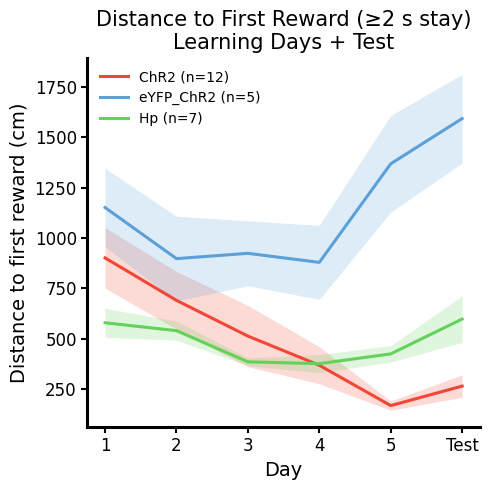

In [233]:
# ============================================================
# Distance to first reward-zone entry
# Plot ChR2 vs eYFP_ChR2 vs Hp
# Metric: dist_to_trigger
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, three genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['dist_to_trigger'].notna())
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST after last L session → day 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # L1–L5 + Test(6)


# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['dist_to_trigger'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp)

print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
print("Hp animals plotted:", len(subs_Hp))


# ---------------------------------------------------------------------
# 3. Plot with shaded SEM
# ---------------------------------------------------------------------
plt.figure(figsize=(5,5))
x_vals = plot_days - 1

def plot_group(mat, subs, gkey, glabel):
    if mat is None:
        return
    col = get_genotype_color(gkey)

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    # shaded SEM
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=0.20,
        linewidth=0
    )

    # mean curve
    plt.plot(
        x_vals, mean_,
        color=col,
        linewidth=2.2,
        label=f'{glabel} (n={len(subs)})'
    )


plot_group(mat_ChR2, subs_ChR2, 'ChR2', 'ChR2')
plot_group(mat_eYFP, subs_eYFP, 'eYFP_ChR2', 'eYFP_ChR2')
plot_group(mat_Hp,   subs_Hp,   'Hp', 'Hp')


# ---------------------------------------------------------------------
# Axes + formatting
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Distance to first reward (cm)', fontsize=14)
plt.title('Distance to First Reward (≥2 s stay)\nLearning Days + Test', fontsize=15)

plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.5)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [228]:
# Compute mean speed per trial

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata['mean_speed'] = np.nan  # cm/s

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)

    # remove zeros / NaNs if needed
    speeds = pos['speed'].values
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        continue

    metadata.at[trial_id, 'mean_speed'] = np.nanmean(speeds)

metadata[['sub','ses','trial_type','trial_type_day','mean_speed']].head()

 15%|█▌        | 708/4611 [00:05<00:27, 143.98it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1182/4611 [00:08<00:22, 151.25it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2616/4611 [00:16<00:07, 266.48it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:28<00:00, 163.96it/s]


,sub,ses,trial_type,trial_type_day,mean_speed
0,1,1,H,1,13.183545
1,1,1,H,1,9.790948
2,1,1,H,1,9.168459
3,1,1,H,1,9.678405
4,1,1,H,1,10.652230


ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


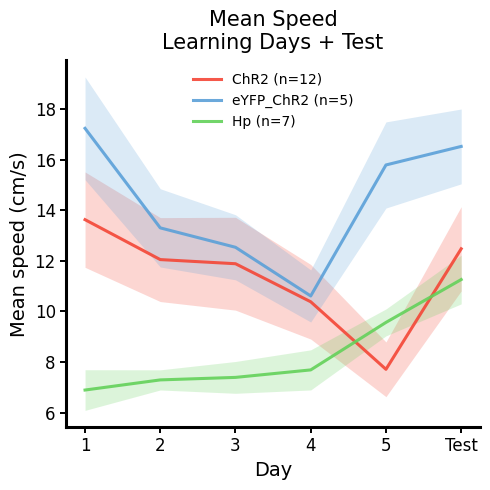

In [229]:
# plot mean speed

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, three genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
  #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &  
   #  (metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['mean_speed'].notna())
].copy()

# Create plot_day: learning = 1–5, test = 6 (assigned per animal)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix (mean_speed), require complete days
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, require_complete=True):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['mean_speed'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2'].copy()
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp'].copy()
#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A'].copy()
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt'].copy()

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2, require_complete=True)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP, require_complete=True)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp,   require_complete=True)

print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
print("Hp animals plotted:", len(subs_Hp))

# ------------------------------------------------------------
# 3) Plot (mean ± shaded SEM only)
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, color, label, alpha_fill=0.22, alpha_line=0.9):

    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    # shaded SEM
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line
    plt.plot(
        x_vals,
        mean_,
        '-',                # line only, no markers
        color=color,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- call for groups using your color function ---
plot_group_shaded(mat_ChR2, subs_ChR2,
                  color=get_genotype_color('ChR2'),
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  color=get_genotype_color('eYFP_ChR2'),
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  color=get_genotype_color('Hp'),
                  label='Hp')

# ------------------------------------------------------------
# axis + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean speed (cm/s)', fontsize=14)

plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)
plt.title('Mean Speed\nLearning Days + Test', fontsize=15, pad=8)
plt.tight_layout()
plt.show()

Animals included (learning trials only):
  ChR2: 12
  eYFP: 5


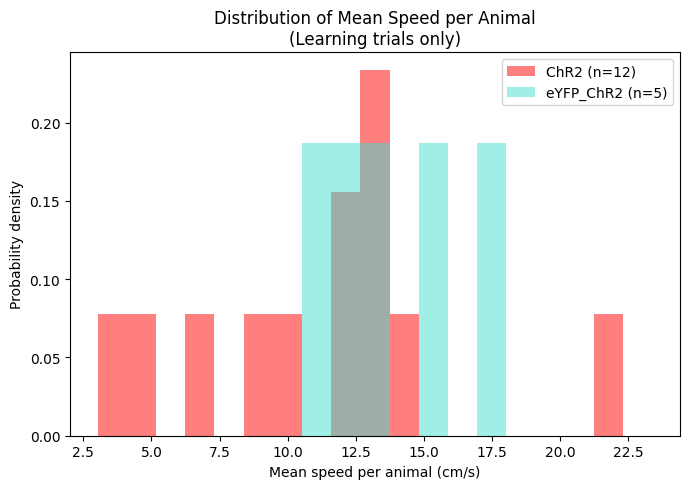

In [65]:
# Distribution of Mean Speed per Animal
# 1) Restrict to LEARNING trials only
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['mean_speed'].notna())
].copy()

# ------------------------------------------------------------
# 2) Per-animal mean speed (average across learning trials)
# ------------------------------------------------------------
meta_animal = (
    meta_L
    .groupby(['genotype', 'sub'])['mean_speed']
    .mean()
    .reset_index()
)

speeds_ChR2 = meta_animal.loc[
    meta_animal['genotype'] == 'ChR2', 'mean_speed'
].values

speeds_eYFP = meta_animal.loc[
    meta_animal['genotype'] == 'eYFP_ChR2', 'mean_speed'
].values

print("Animals included (learning trials only):")
print("  ChR2:", len(speeds_ChR2))
print("  eYFP:", len(speeds_eYFP))

# ------------------------------------------------------------
# 3) Plot histogram
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

bins = np.linspace(
    np.nanmin(meta_animal['mean_speed']),
    np.nanmax(meta_animal['mean_speed']),
    20
)

plt.hist(
    speeds_ChR2,
    bins=bins,
    color='red',
    alpha=0.5,
    density=True,
    label=f'ChR2 (n={len(speeds_ChR2)})'
)

plt.hist(
    speeds_eYFP,
    bins=bins,
    color='turquoise',
    alpha=0.5,
    density=True,
    label=f'eYFP_ChR2 (n={len(speeds_eYFP)})'
)

plt.xlabel('Mean speed per animal (cm/s)')
plt.ylabel('Probability density')
plt.title('Distribution of Mean Speed per Animal\n(Learning trials only)')
plt.legend()
plt.tight_layout()
plt.show()

Speed samples per day:
  Day 1: 456899
  Day 2: 443936
  Day 3: 466650
  Day 4: 437309
  Day 5: 423805
  Day 6: 56880


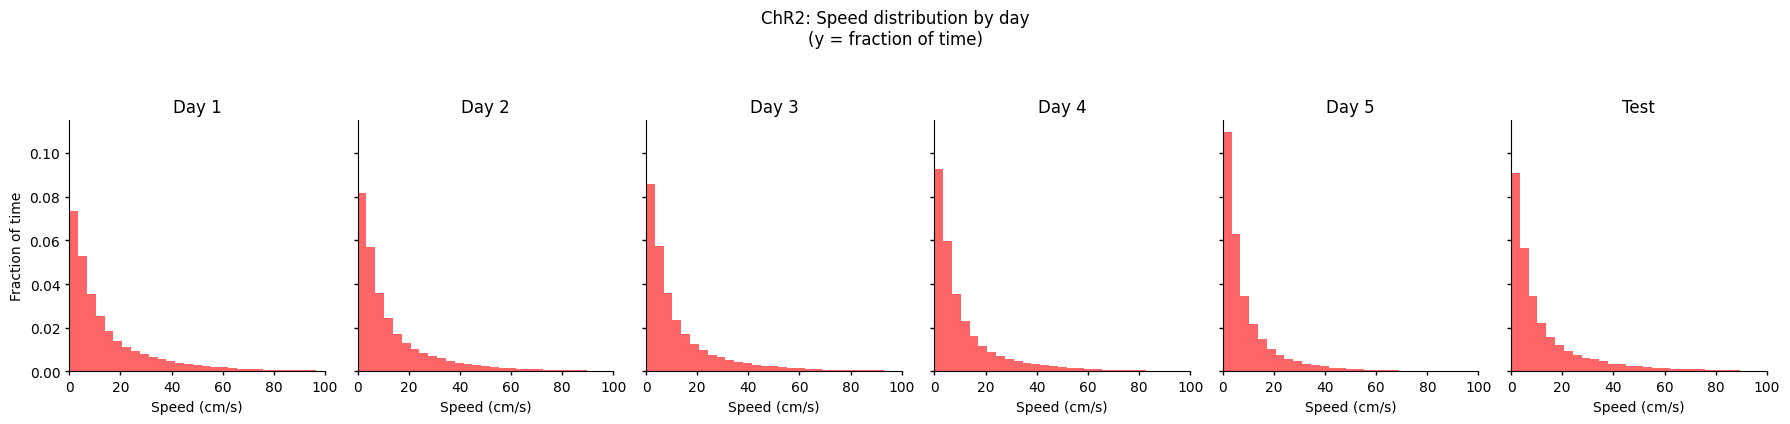

In [ ]:
# =============================================================
# Speed distribution by day (ChR2: L1–L5 + Test)
# =============================================================

days = [1, 2, 3, 4, 5, 6]  # now includes test as day 6

# ------------------------------------------------------------
# 1) Filter usable trials for ChR2 (L + T)
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L','T']))
].copy()

# assign learning trial days 1–5
meta_LT.loc[meta_LT['trial_type']=='L', 'plot_day'] = meta_LT['trial_type_day']

# ------------------------------------------------------------
# 2) Assign FIRST TEST session after learning → plot_day = 6
# ------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub']==sub]

    L_ses = ms.loc[ms['trial_type']=='L', 'ses']
    if len(L_ses)==0:
        continue
    last_L = L_ses.max()

    T_after = ms[(ms['trial_type']=='T') & (ms['ses'] > last_L)]
    if len(T_after)==0:
        continue

    first_T = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub']==sub) &
        (meta_LT['trial_type']=='T') &
        (meta_LT['ses']==first_T)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# keep only days 1–6
meta_LT = meta_LT[meta_LT['plot_day'].isin(days)]

# ------------------------------------------------------------
# 3) Collect SPEED samples per plot_day
# ------------------------------------------------------------
speed_by_day = {d: [] for d in days}

for idx, row in meta_LT.iterrows():
    dl = DataLoader(row)
    pos = dl.get_data('position')
    if pos is None or len(pos)<2:
        continue

    pos = add_speed(pos)
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]
    speeds = speeds[speeds>0]

    if len(speeds)==0:
        continue
    
    speed_by_day[int(row['plot_day'])].append(speeds)

# concatenate
for d in days:
    speed_by_day[d] = np.concatenate(speed_by_day[d]) if len(speed_by_day[d])>0 else np.array([])

print("Speed samples per day:")
for d in days:
    print(f"  Day {d}: {len(speed_by_day[d])}")

# ------------------------------------------------------------
# 4) Plot histograms (fraction of time)
# ------------------------------------------------------------

col = get_genotype_color('ChR2')
bins = np.linspace(0, 100, 30)

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=True)

labels = {1:'Day 1', 2:'Day 2', 3:'Day 3', 4:'Day 4', 5:'Day 5', 6:'Test'}

for ax, d in zip(axes, days):
    speeds = speed_by_day[d]
    
    ax.hist(
        speeds,
        bins=bins,
        density=True,
        color=col,
        alpha=0.8,
        edgecolor='none'
    )
    
    ax.set_xlim(0,100)
    ax.set_title(labels[d])
    ax.set_xlabel('Speed (cm/s)')
    if d == 1:
        ax.set_ylabel('Fraction of time')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)

fig.suptitle('ChR2: Speed distribution by day\n(y = fraction of time)',
             y=1.05, fontsize=12)

plt.tight_layout()
plt.show()

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.
ChR2 animals plotted: 12


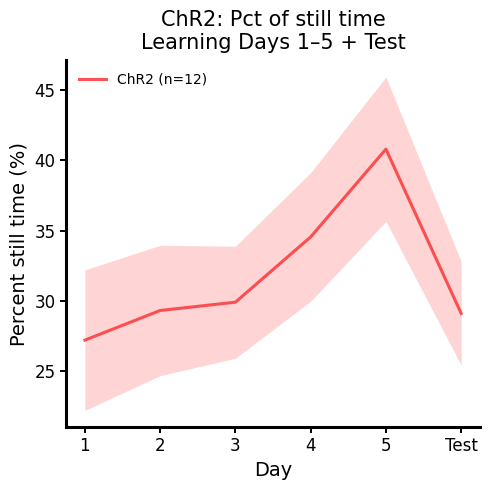

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Compute % still time per trial (using speed threshold)
# ============================================================

STILL_THRESH = 2.0  # cm/s, change if you like

# add column if not present
if 'pct_still' not in metadata.columns:
    metadata['pct_still'] = np.nan

for trial_id in range(len(metadata)):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)  # must create pos['speed']
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        continue

    pct_still = 100.0 * np.mean(speeds < STILL_THRESH)
    metadata.at[trial_id, 'pct_still'] = pct_still

# ============================================================
# 2) Build L1–5 + Test (day 6) for ChR2 only
# ============================================================

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_still'].notna())
].copy()

# init plot_day
meta_LT['plot_day'] = np.nan

# L trials: trial_type_day 1–5
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# assign first T session after last L as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1–5 + Test
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)]

# ============================================================
# 3) Subject × day matrix: % still time
# ============================================================

def build_matrix_pct_still(meta_g, require_complete=True):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_still'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs

mat_ChR2, subs_ChR2 = build_matrix_pct_still(meta_LT, require_complete=True)
print("ChR2 animals plotted:", len(subs_ChR2))

# ============================================================
# 4) Plot mean ± shaded SEM (ChR2 only)
# ============================================================

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 (for label convenience)

col = get_genotype_color('ChR2')

if mat_ChR2 is not None and len(subs_ChR2) > 0:
    mean_ = np.nanmean(mat_ChR2, axis=0)
    sem_  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])

    # shaded SEM
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=0.22,
        linewidth=0
    )

    # mean line (no markers if you don’t want dots)
    plt.plot(
        x_vals, mean_,
        '-',                # use '-' to avoid dots; '-o' if you want dots
        color=col,
        alpha=0.9,
        linewidth=2.2,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# axes + style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent still time (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('ChR2: Pct of still time\nLearning Days 1–5 + Test', fontsize=15, pad=8)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [99]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# (optionally require ≥2000 ms stay)
# ------------------------------------------------------------

metadata['mean_speed_to_trigger'] = np.nan

R_TRIGGER = (10 / 1.2)

# ----------------------------
# TOGGLE THIS
# ----------------------------
USE_MIN_DURATION = False      # set False to ignore duration
MIN_DURATION_MS = 2000       # ms
# ----------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    # add speed + distance info
    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect all trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # never entered any reward zone
    if len(dfs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    # ----------------------------
    # OPTIONAL: require ≥2000 ms stay
    # ----------------------------
    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        # never satisfied criterion → use full trial
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue
    # ----------------------------

    # first qualifying entry time
    t_enter_first = df_all.iloc[0]['t_enter']

    # speed up to that time
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = 0.0
        continue

    metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(
        pos_['speed'].iloc[idxs]
    )

 15%|█▌        | 704/4611 [00:06<00:35, 110.83it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1184/4611 [00:10<00:28, 121.13it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2617/4611 [00:21<00:11, 178.52it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:36<00:00, 124.88it/s]


Animals plotted:
  ChR2: 10
  eYFP: 5


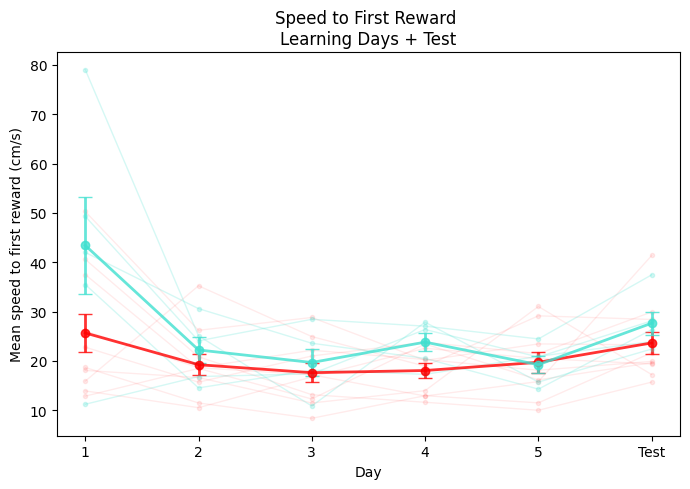

In [100]:
# Speed to first reward zone entry
# Plot ChR2 vs eYFP_ChR2 vs Hp

# ------------------------------------------------------------
# 1) Filter metadata 
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
   # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
        ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['mean_speed_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Assign plot_day (L = 1–5, first T after learning = 6)
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan
meta_LT.loc[meta_LT['trial_type'] == 'L', 'plot_day'] = meta_LT['trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 3) Subject × day matrix
# ------------------------------------------------------------
def build_matrix(meta_g):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]
        mean_by_day = ms.groupby('plot_day')['mean_speed_to_trigger'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs


#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
#meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_matrix(meta_eYFP)
#mat_Hp,   subs_Hp   = build_matrix(meta_Hp)

print("Animals plotted:")
print("  ChR2:", len(subs_ChR2))
print("  eYFP:", len(subs_eYFP))
#print("  Hp  :", len(subs_Hp))

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------

SHOW_INDIVIDUALS = True   # <<< TOGGLE THIS (True / False)

plt.figure(figsize=(7, 5))
x = plot_days - 1

def plot_group(mat, color, label, alpha_mean=0.7, alpha_ind=0.15):
    if mat is None or mat.shape[0] == 0:
        return

    # ----------------------------
    # individual animals (optional)
    # ----------------------------
    if SHOW_INDIVIDUALS:
        for row in mat:
            plt.plot(
                x, row, '-o',
                color=color,
                alpha=alpha_ind,
                linewidth=1,
                markersize=3,
                label='_nolegend_'
            )

    # ----------------------------
    # mean ± SEM
    # ----------------------------
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        alpha=alpha_mean,
        linewidth=2,
        capsize=5,
        label=f'{label} (n={mat.shape[0]})'
    )


plot_group(mat_ChR2, 'red',        'ChR2',       alpha_mean=0.8, alpha_ind=0.08)
plot_group(mat_eYFP, 'turquoise',  'eYFP_ChR2',  alpha_mean=0.8, alpha_ind=0.22)
#plot_group(mat_Hp,   '#2ca02c',    'Hp',         alpha_mean=0.8)

plt.xlabel('Day')
plt.ylabel('Mean speed to first reward (cm/s)')
plt.title('Speed to First Reward \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'])
#plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [32]:
# Compute time to arrive in reward zone

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # <-- only recruit the trials if usable = 1

# Define a column in metadata to save the time to trigger zone
metadata['t_to_trigger'] = 0
# Define another column to save if animal ever learned to stay at the trigger zone
metadata['learned'] = False

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue
    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti = i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    # Find time to trigger
    df_all_triggers_long = df_all_triggers[df_all_triggers['duration']>=2000]
    # decide if we want visits with duration > 2000 ms (2 s) only or all visits
         #df_all_triggers_long = df_all_triggers
    
    if len(df_all_triggers_long) == 0:
        # If animal never spent more than dt in the trigger zone, time to trigger is equal to the duration of the trial
        t_to_trigger = position_.iloc[-1]['t']
        
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True
    


    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger





 15%|█▌        | 709/4609 [00:07<00:38, 100.55it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1176/4609 [00:12<00:33, 102.32it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 56%|█████▋    | 2604/4609 [00:24<00:12, 157.62it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:41<00:00, 110.90it/s]


ChR2 long animals plotted : 12
ChR2 short animals plotted: 4
eYFP_ChR2 animals plotted : 5
Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = 0.111


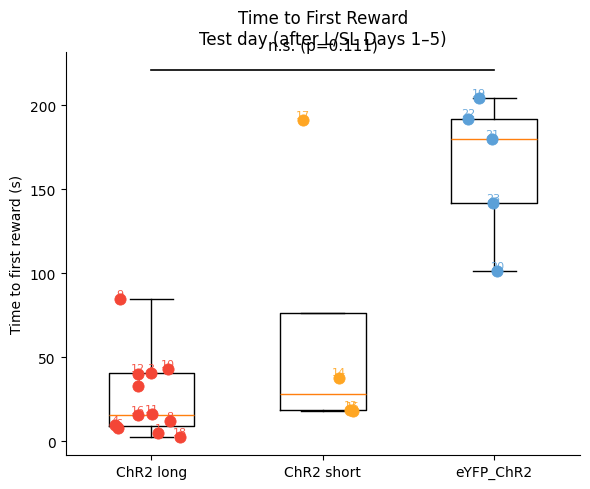

In [ ]:
To be revised!!! compute box plot
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 0) Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
#     (assumes metadata already has t_to_trigger from your code)
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T'])) &
    (metadata['t_to_trigger'].notna())
].copy()

plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1) Helper: build subject × day matrix for t_to_trigger (ms)
#    learning_type: 'L' or 'SL'
#    First T session AFTER last learning session is day 6
# ------------------------------------------------------------
def build_group_matrix_t(meta_all, genotype, learning_type='L',
                         short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) t_to_trigger (ms) per day
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # learning trials (L or SL) for this animal
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # use trial_type_day (1–5) as learning days
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # only keep learning days 1–5
        ms.loc[mL.index, 'plot_day'] = ms.loc[mL.index, 'plot_day'].clip(1, 5)

        # ----- KEY: first T session AFTER last learning session -----
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean t_to_trigger (ms) per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2) Build matrices for the three groups
#    Group 1: ChR2 long (L, short_duration=0)
#    Group 2: eYFP_ChR2 (L, any short_duration)
#    Group 3: ChR2 short (SL, short_duration=1)
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix_t(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix_t(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix_t(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted :", len(subs_ChR2_long))
print("ChR2 short animals plotted:", len(subs_ChR2_short))
print("eYFP_ChR2 animals plotted :", len(subs_eYFP))


# ------------------------------------------------------------
# 3) Extract TEST DAY (day 6) values for each animal (ms → s)
#     matrices are (n_animals x 6), index 5 = test day
# ------------------------------------------------------------
vals_ChR2_long_ms  = mat_ChR2_long[:, 5]    # day 6
vals_ChR2_short_ms = mat_ChR2_short[:, 5]
vals_eYFP_ms       = mat_eYFP[:, 5]

vals_ChR2_long  = vals_ChR2_long_ms  / 1000.0   # seconds
vals_ChR2_short = vals_ChR2_short_ms / 1000.0
vals_eYFP       = vals_eYFP_ms       / 1000.0

groups = ['ChR2 long', 'ChR2 short', 'eYFP_ChR2']
data   = [vals_ChR2_long, vals_ChR2_short, vals_eYFP]

colors = {
    'ChR2 long'  : get_genotype_color('ChR2'),
    'ChR2 short' : get_genotype_color('ChR2_short'),
    'eYFP_ChR2'  : get_genotype_color('eYFP_ChR2')
}


# ------------------------------------------------------------
# 4) Plot boxplot + jittered animal points
# ------------------------------------------------------------
# ------------------------------------------------------------
# 4) Plot boxplot + jittered animal points + animal labels
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,
    showfliers=False
)

for i, g in enumerate(groups):
    vals = data[i]
    subs = [subs_ChR2_long, subs_ChR2_short, subs_eYFP][i]   # matching subject lists
    n = len(vals)

    jitter = 0.12
    x = np.random.normal(i, jitter, size=n)

    # plot points
    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

    # add labels (animal IDs)
    for xi, yi, sub in zip(x, vals, subs):
        plt.text(
            xi, yi + 0.05,   # offset upward
            str(sub),
            ha='center', va='bottom',
            fontsize=8,
            rotation=0,
            color=colors[g],
            alpha=0.9
        )

# ------------------------------------------------------------
# 5) Rank-sum (Mann–Whitney) for ChR2_long vs eYFP_ChR2
#    (line between box 0 and box 2; ChR2_short is box 1)
# ------------------------------------------------------------
vals_ch = vals_ChR2_short
vals_yf = vals_eYFP

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax  = np.nanmax(np.concatenate([vals_ChR2_long, vals_ChR2_short, vals_eYFP]))
y_line = ymax * 1.08
y_star = ymax * 1.13

plt.plot([0, 0, 2, 2], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

plt.text(
    1.0, y_star,
    f"{stars} (p={p:.3g})",
    ha='center', va='bottom', fontsize=11
)


# ------------------------------------------------------------
# 6) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylabel('Time to first reward (s)')
plt.xlabel('')
plt.title('Time to First Reward\nTest day (after L/SL Days 1–5)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x12224e210>,
 [Text(0, 0, 'Day 1'),
  Text(1, 0, 'Day 2'),
  Text(2, 0, 'Day 3'),
  Text(3, 0, 'Day 4'),
  Text(4, 0, 'Day 5')])

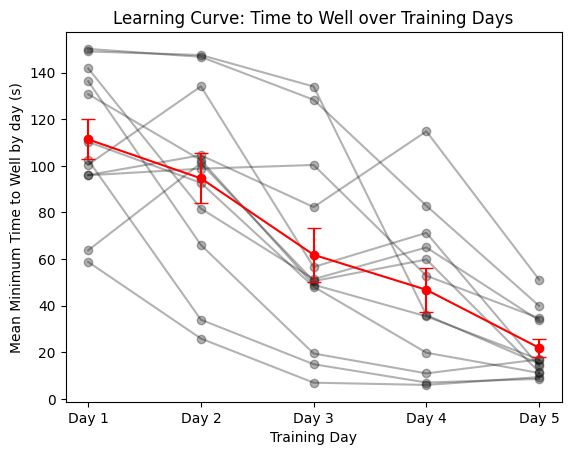

In [50]:
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
    ].reset_index(drop=True)

# 

performance_mat = []
for sub in metadata_L['sub'].unique():
    metadata_L_A = metadata_L[metadata_L['sub'] == sub]#.reset_index(drop=True)
    mean_performance_by_day = metadata_L_A.groupby('trial_type_day')['t_to_trigger'].mean().values
    if len(mean_performance_by_day)!=5:
        continue
    performance_mat.append(mean_performance_by_day)
    plt.plot(range(0,5), mean_performance_by_day/1000, '-o',color='k', alpha=0.3)

performance_mat = np.vstack(performance_mat)
# Get the mean and standard error across subjects
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])
plt.errorbar(range(0,5), mean_performance/1000, yerr=sem_performance/1000, fmt='-o', color='r', capsize=5)
plt.xlabel('Training Day')
plt.ylabel('Mean Minimum Time to Well by day (s)')
plt.title('Learning Curve: Time to Well over Training Days')

plt.xticks(range(0,5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])

ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6


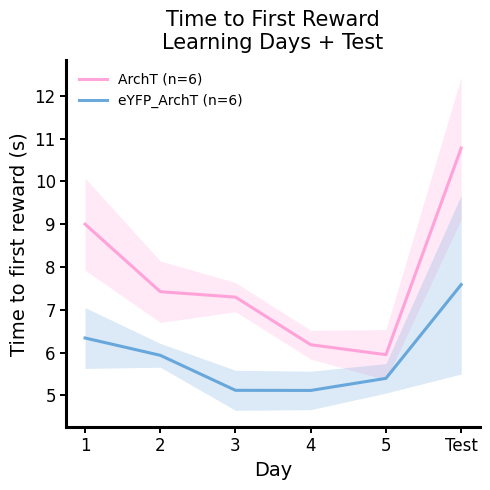

In [225]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, ArchT / eYFP_ArchT, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['t_to_trigger'] != 0)          # exclude trials with no latency data
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue  # this animal has no post-learning test session

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# Learning days 1–5 + Test day 6
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector (in ms)
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days],
                        dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ArchT      = meta_LT[meta_LT['genotype'] == 'ArchT']
meta_eYFP_ArchT = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']

mat_ArchT,      subs_ArchT      = build_genotype_matrix(meta_ArchT)
mat_eYFP_ArchT, subs_eYFP_ArchT = build_genotype_matrix(meta_eYFP_ArchT)

print("ArchT animals plotted:", len(subs_ArchT))
print("eYFP_ArchT animals plotted:", len(subs_eYFP_ArchT))

# ---------------------------------------------------------------------
# 3. Plot: mean curves + shaded SEM, using colour function
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) t_to_trigger in ms
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ArchT')
    """
    if mat is None or len(subs) == 0:
        return

    # convert ms → s
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals, mean_s,
        '-',                    # no markers; use '-o' if you want dots
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# Plot ArchT + eYFP_ArchT
plot_group_shaded(mat_ArchT,      subs_ArchT,
                  genotype_key='ArchT',
                  label='ArchT')

plot_group_shaded(mat_eYFP_ArchT, subs_eYFP_ArchT,
                  genotype_key='eYFP_ArchT',
                  label='eYFP_ArchT')

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Time to First Reward\nLearning Days + Test',
          fontsize=15, pad=8)
#(≥2 s stay)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in dataset: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in dataset: 5
eYFP_ChR2 animals plotted: 5


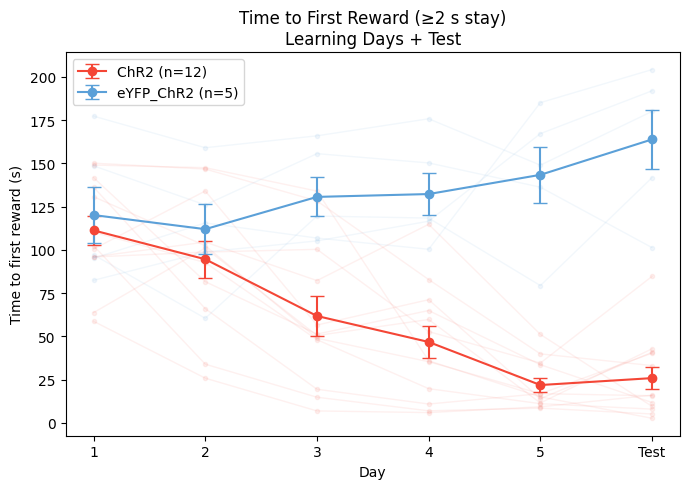

In [253]:
# time to arrive at new reward ChR2 vs YFP and stayed there for at least 2 sec

# Plot ChR2 & eYFP_ChR2 learning trials + first test day by session
# Metric: time to first reward (t_to_trigger), in seconds

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # this animal has no test day

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect 6 days: L1–L5 + Test
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in dataset:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in dataset:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot (using colour function)
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# grab colours from your function
col_ChR2 = get_genotype_color('ChR2')
col_eYFP = get_genotype_color('eYFP_ChR2')

# ---- ChR2 ----
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(
            x_vals, row / 1000,
            '-o',
            color=col_ChR2,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c / 1000, yerr=sem_c / 1000,
        fmt='-o',
        color=col_ChR2,
        capsize=5,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# ---- eYFP_ChR2 ----
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(
            x_vals, row / 1000,
            '-o',
            color=col_eYFP,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y / 1000, yerr=sem_y / 1000,
        fmt='-o',
        color=col_eYFP,
        capsize=5,
        label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay)\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

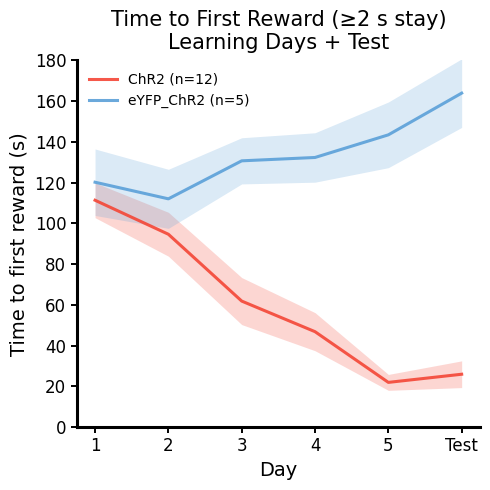

In [254]:
# time to first reward - clean figure

# ---------------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, journal-style
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) time-to-trigger in ms
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2')
    """
    if mat is None or len(subs) == 0:
        return

    # convert ms → s
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals, mean_s,
        '-',                    # no markers; use '-o' if you want dots
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# --- plot both groups using your color function ---
plot_group_shaded(mat_ChR2, subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2')

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Time to First Reward (≥2 s stay)\nLearning Days + Test',
          fontsize=15, pad=8)

#(≥2 s stay)

plt.legend(frameon=False)
plt.ylim(0, 180)   # set min/max
plt.tight_layout()
plt.show()

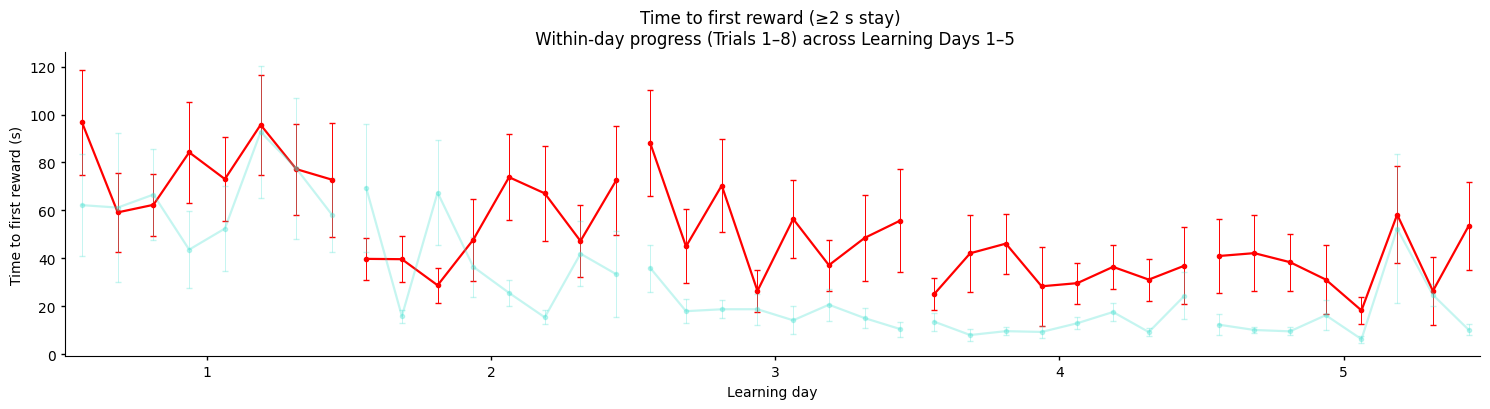

In [ ]:

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    #(metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,        # <-- add this
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# Split by genotype
meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()

# Wider figure so Day 5 curve isn't clipped
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red', alpha=1.0)
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # <-- more faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Centered day ticks
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure Day 5 curve fully visible

ax.set_xlim(1.0, 5.98)

ax.set_title('Time to first reward (≥2 s stay) \n Within-day progress (Trials 1–8) across Learning Days 1–5', fontsize=12)
#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5
  Hp: 7


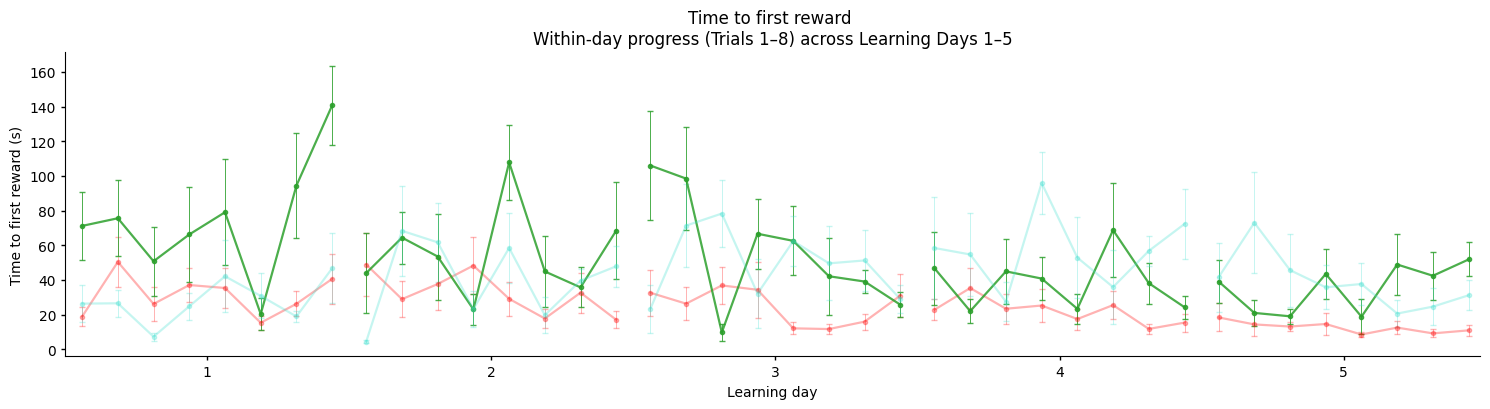

In [ ]:
# Plot ChR2 vs eYFP_ChR2 vs Hp learning trials

# ------------------------------------------------------------
# 1) Filter: usable animals, include 3 genotypes, L only, days 1–5
#    exclude short_duration==1 and exclude missing t_to_trigger (==0)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    # fallback: infer by order within (sub, ses)
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        # keep subject if they have at least 1 trial that day
        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
#    (group mean ± SEM; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points inside each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0  # ms -> s
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            elinewidth=0.7,   # thinner SEM bars
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes (no top/right box)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype (3 groups)
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
print("  Hp:", meta_Hp['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day ticks; extra room for day 5 curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red',       alpha=0.3)
plot_within_day_curves(ax, meta_Hp,   color='#2ca02c',   alpha=0.85)  # Hp in green
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # control faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Center x tick labels under each day's curve (middle of the curve)
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Tighten left space + ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Time to first reward \n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Animals included (n):
  ChR2 long (L, short_duration=0): 12
  eYFP_ChR2 (L): 5
  ChR2 short (SL, short_duration=1): 4


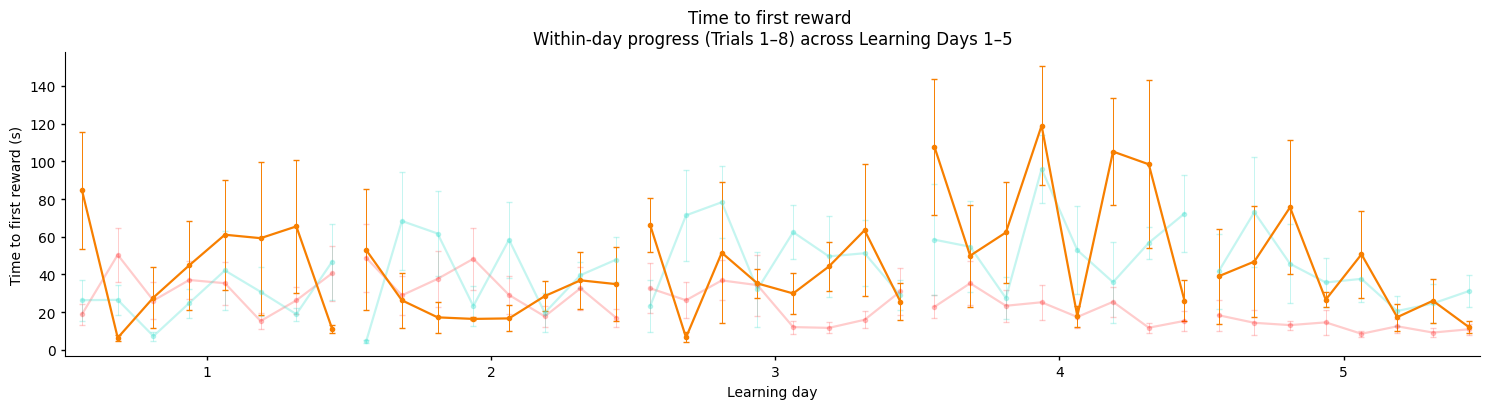

In [ ]:
# Plot ChR2 long L vs eYFP L vs ChR2 short SL learning trials
# ------------------------------------------------------------
# 0) Base filter: usable, relevant genotypes, L/SL learning days 1–5
#    (exclude missing t_to_trigger == 0)
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 1) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_all.columns), None)

if trial_col is not None:
    meta_all['trial_in_day'] = meta_all[trial_col].astype(int)
else:
    meta_all = meta_all.sort_values(['sub', 'ses']).copy()
    meta_all['trial_in_day'] = meta_all.groupby(['sub', 'ses']).cumcount() + 1

meta_all = meta_all[meta_all['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 2) Helper: subject×trial matrix for a given day (allow missing trials)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None
    return np.vstack(rows)

# ------------------------------------------------------------
# 3) Build per-group meta for within-day curves
#    (Group 1: ChR2 long L; Group 2: eYFP L; Group 3: ChR2 short SL)
# ------------------------------------------------------------
def select_group(meta_all, genotype, learning_type='L', short_duration_val=None):
    m = meta_all[
        (meta_all['genotype'] == genotype) &
        (meta_all['trial_type'] == learning_type)
    ].copy()
    if short_duration_val is not None:
        m = m[m['short_duration'] == short_duration_val].copy()
    return m

meta_ChR2_long = select_group(meta_all, 'ChR2', learning_type='L',  short_duration_val=0)
meta_eYFP      = select_group(meta_all, 'eYFP_ChR2', learning_type='L', short_duration_val=None)
meta_ChR2_short= select_group(meta_all, 'ChR2', learning_type='SL', short_duration_val=1)

print("Animals included (n):")
print("  ChR2 long (L, short_duration=0):", meta_ChR2_long['sub'].nunique())
print("  eYFP_ChR2 (L):", meta_eYFP['sub'].nunique())
print("  ChR2 short (SL, short_duration=1):", meta_ChR2_short['sub'].nunique())

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# ChR2 long – red
plot_within_day_curves(ax, meta_ChR2_long, color='red', alpha=0.2)

# eYFP control – turquoise, faded
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)

# ChR2 short (SL) – orange
plot_within_day_curves(ax, meta_ChR2_short, color='#f77f00', alpha=1)

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# center day labels under each day's curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Time to first reward \n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)
#(≥2 s stay)


style_nature(ax)
plt.tight_layout()
plt.show()

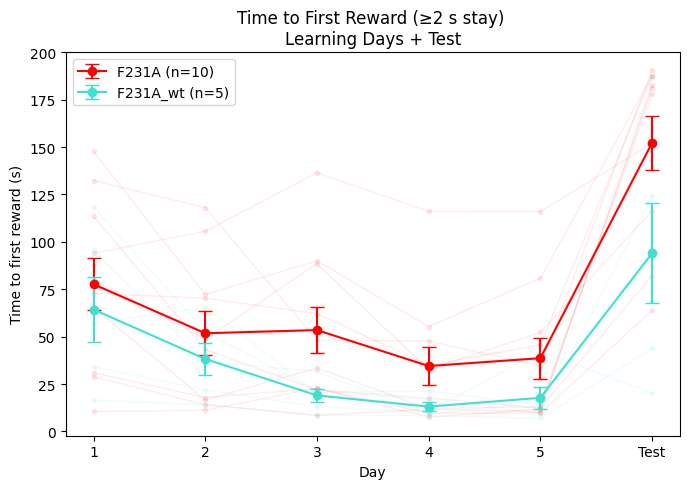

In [59]:
# time to arrive at new reward Ingo Greger animals - F231A vs wt and stayed there for at least 2 sec

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
             ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['t_to_trigger'] != 0)          # <-- exclude animals/trials with no data yet
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # this animal has no test day

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect 6 days: L1–L5 + Test
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_F231A = meta_LT[meta_LT['genotype'] == 'F231A']
meta_F231A_wt = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_F231A, subs_F231A = build_genotype_matrix(meta_F231A)
mat_F231A_wt, subs_F231A_wt = build_genotype_matrix(meta_F231A_wt)



# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ---- ChR2 (red) ----
if mat_F231A is not None:
    # individual traces
    for row in mat_F231A:
        plt.plot(x_vals, row / 1000, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    # mean ± SEM
    mean_c = np.nanmean(mat_F231A, axis=0)
    sem_c  = np.nanstd(mat_F231A, axis=0) / np.sqrt(mat_F231A.shape[0])
    plt.errorbar(
        x_vals, mean_c / 1000, yerr=sem_c / 1000,
        fmt='-o', color='red', capsize=5,
        label=f'F231A (n={len(subs_F231A)})'
    )

# ---- eYFP (turquoise) ----
if mat_F231A_wt is not None:
    for row in mat_F231A_wt:
        plt.plot(x_vals, row / 1000, '-o', color='turquoise', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    mean_y = np.nanmean(mat_F231A_wt, axis=0)
    sem_y  = np.nanstd(mat_F231A_wt, axis=0) / np.sqrt(mat_F231A_wt.shape[0])
    plt.errorbar(
        x_vals, mean_y / 1000, yerr=sem_y / 1000,
        fmt='-o', color='turquoise', capsize=5,
        label=f'F231A_wt (n={len(subs_F231A_wt)})'
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay) \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()



ChR2 long (short_duration=0) animals in data: 12
ChR2 long animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
ChR2 short (short_duration=1) animals in data: 4
ChR2 short animals plotted: 4


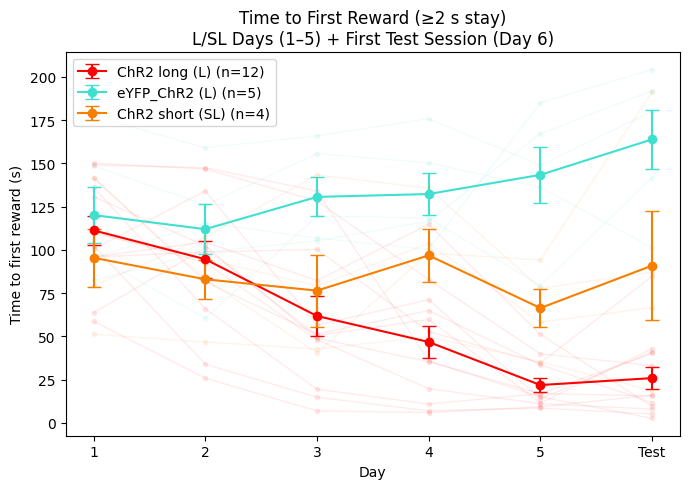

In [171]:
# time to arrive at reward ChR2 vs short_duration vs YFP and stayed there for at least 2 sec

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
#    (don't filter on short_duration here; we handle per-group)
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # L1–L5 + Test


# ------------------------------------------------------------
# 1. Helper to build subject × day matrix for a given group
#    learning_type: 'L' (normal) or 'SL' (short-duration learning)
#    short_duration_val: None (no filter), 0 or 1
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type, short_duration_val=None,
                       require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) t_to_trigger (ms)
      - subjects: list of subject IDs
    learning_type: 'L' or 'SL'
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> keep only those rows with that short_duration
    """
    # subset by genotype and learning trial type + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    # We'll create a plot_day per animal *for this group*
    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # Reset plot_day (so we don't reuse from other groups)
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Assign learning days = trial_type_day (expected 1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # Use 'ses' to find first T session after the last learning session
        last_L_ses = mL['ses'].max()

        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            # no test after learning for this animal in this group
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # Now compute mean t_to_trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # Build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce complete 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration = 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: ChR2, short_duration = 1, learning_type = 'SL'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 controls
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short-duration -> use SL trials as learning
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True  # can relax to False if needed
)

print("ChR2 long (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 long animals plotted:", len(subs_ChR2_long))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("ChR2 short (short_duration=1) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 1)]['sub'].nunique())
print("ChR2 short animals plotted:", len(subs_ChR2_short))

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # Individual traces (more faded)
    for row in mat:
        plt.plot(x_vals, row / 1000, '-o', color=color, alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # Group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_ / 1000, yerr=sem_ / 1000,
        fmt='-o', color=color, capsize=5,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 long – red
plot_group(mat_ChR2_long, subs_ChR2_long, color='red', label='ChR2 long (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: ChR2 short – more orange
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay)\nL/SL Days (1–5) + First Test Session (Day 6)')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

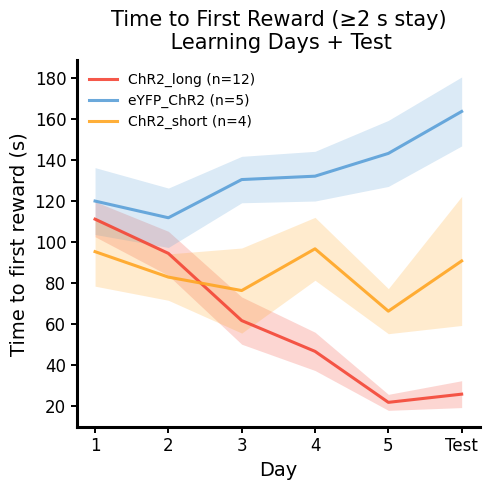

In [172]:
# ------------------------------------------------------------
# 3) Plot (mean ± shaded SEM only)
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):

    if mat is None or len(subs) == 0:
        return

    color = get_genotype_color(genotype_key)

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    # shaded SEM
    plt.fill_between(
        x_vals,
        (mean_ - sem_) / 1000,
        (mean_ + sem_) / 1000,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line
    plt.plot(
        x_vals,
        mean_ / 1000,
        '-',
        color=color,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# --- GROUPS ---
plot_group_shaded(mat_ChR2_long, subs_ChR2_long,
                  genotype_key='ChR2', label='ChR2_long')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2', label='eYFP_ChR2')

plot_group_shaded(mat_ChR2_short, subs_ChR2_short,
                  genotype_key='ChR2_short', label='ChR2_short')


# ------------------------------------------------------------
# Axes + Style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward (s)', fontsize=14)

plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)
plt.title('Time to First Reward (≥2 s stay)\n Learning Days + Test', fontsize=15, pad=8)
# (≥2 s stay)
plt.tight_layout()
plt.show()

ChR2 (short_duration=0) animals in data: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
Hp animals in data: 7
Hp animals plotted: 7


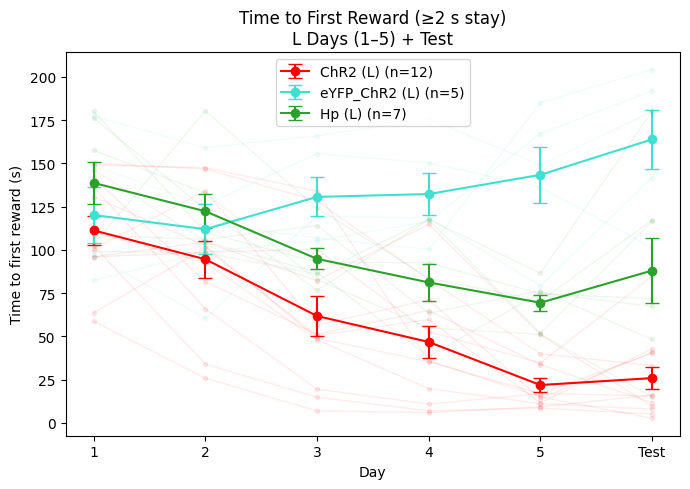

In [173]:
# time to arrive at reward: ChR2 vs eYFP_ChR2 vs Hp
# L days + first T session after learning; stayed there for at least 2 sec (via t_to_trigger)

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

plot_days = np.arange(1, 7)  # L1–L5 + Test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for a given group
#    learning_type: 'L' (we’re not using SL anymore here)
#    short_duration_val: None (no filter), 0 or 1
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L', short_duration_val=None,
                       require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) t_to_trigger (ms)
      - subjects: list of subject IDs

    learning_type: usually 'L'
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> keep only those rows with that short_duration
    """
    # subset by genotype and learning trial type + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # Reset plot_day for this animal
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Assign learning days = trial_type_day (expected 1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # Use 'ses' to find first T session after the last learning session
        last_L_ses = mL['ses'].max()

        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            # no test after learning for this animal
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # Now compute mean t_to_trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # Build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce complete 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration = 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: Hp, any short_duration, learning_type = 'L'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2, subs_ChR2 = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: Hp
mat_Hp, subs_Hp = build_group_matrix(
    meta_all,
    genotype='Hp',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

print("ChR2 (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("Hp animals in data:",
      meta_all[meta_all['genotype'] == 'Hp']['sub'].nunique())
print("Hp animals plotted:", len(subs_Hp))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # Individual traces (faded)
    for row in mat:
        plt.plot(x_vals, row / 1000, '-o', color=color, alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # Group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_ / 1000, yerr=sem_ / 1000,
        fmt='-o', color=color, capsize=5,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 – red
plot_group(mat_ChR2, subs_ChR2, color='red', label='ChR2 (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: Hp – green
plot_group(mat_Hp, subs_Hp, color='#2ca02c', label='Hp (L)')

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay)\nL Days (1–5) + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

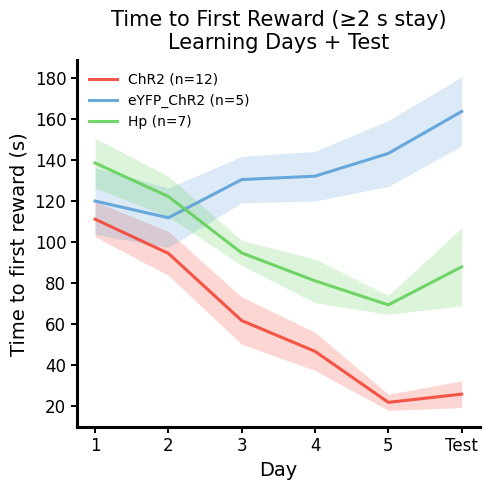

In [174]:
# ------------------------------------------------------------
# 3. Plot (mean ± shaded SEM only)
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):

    if mat is None or len(subs) == 0:
        return

    color = get_genotype_color(genotype_key)

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    # shaded SEM (convert ms → s)
    plt.fill_between(
        x_vals,
        (mean_ - sem_) / 1000.0,
        (mean_ + sem_) / 1000.0,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (ms → s)
    plt.plot(
        x_vals,
        mean_ / 1000.0,
        '-',
        color=color,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- draw groups using your colour function keys ---
plot_group_shaded(mat_ChR2,  subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2')

plot_group_shaded(mat_eYFP,  subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp,    subs_Hp,
                  genotype_key='Hp',
                  label='Hp')

# ------------------------------------------------------------
# Axes + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)
plt.title('Time to First Reward (≥2 s stay)\nLearning Days + Test', fontsize=15, pad=8)
# (≥2 s stay)
plt.tight_layout()
plt.show()

Mann–Whitney U (ChR2 vs eYFP_ChR2) p = 0.000323
Mann–Whitney U (Hp vs eYFP_ChR2) p = 0.048


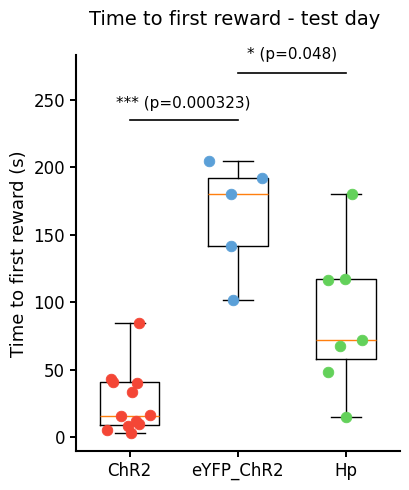

In [264]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# Assume you already have per-animal test-day values in seconds:
#   vals_ChR2, vals_eYFP, vals_Hp
#   (e.g. extracted from column 5 of your t_to_trigger matrices / 1000)
# ------------------------------------------------------------

groups = ['ChR2', 'eYFP_ChR2', 'Hp']   # order: ChR2, YFP, Hp

vals_groups = [
    vals_ChR2,
    vals_eYFP,
    vals_Hp
]

colors = {
    'ChR2'      : get_genotype_color('ChR2'),
    'eYFP_ChR2' : get_genotype_color('eYFP_ChR2'),
    'Hp'        : get_genotype_color('Hp')
}

plt.figure(figsize=(4.2, 5))

# -----------------------------
# Boxplot (one box per genotype)
# -----------------------------
bp = plt.boxplot(
    vals_groups,
    positions=np.arange(len(groups)),
    widths=0.55,
    patch_artist=False,   # keep simple black boxes
    showfliers=False      # hide outlier dots
)

# -----------------------------
# Jittered animal points
# -----------------------------
for i, g in enumerate(groups):
    vals = vals_groups[i]
    jitter = 0.12
    x = np.random.normal(i, jitter, size=len(vals))
    plt.scatter(
        x, vals,
        s=58,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# -----------------------------
# Stats helper
# -----------------------------
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "ns"

# -----------------------------
# Rank-sum: ChR2 vs eYFP
# -----------------------------
vals_ch = vals_ChR2
vals_yf = vals_eYFP
vals_hp = vals_Hp

stat1, p1 = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U (ChR2 vs eYFP_ChR2) p = {p1:.3g}")

# -----------------------------
# Rank-sum: Hp vs eYFP
# -----------------------------
stat2, p2 = mannwhitneyu(vals_hp, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U (Hp vs eYFP_ChR2) p = {p2:.3g}")

# -----------------------------
# Draw significance bars + text
# -----------------------------
all_vals = np.concatenate([vals_ch, vals_yf, vals_hp])
ymax = np.nanmax(all_vals)

# bar positions
y1 = ymax * 1.15   # for ChR2 vs eYFP (0 vs 1)
y2 = ymax * 1.32   # for Hp vs eYFP (2 vs 1)

# ChR2 vs eYFP (x=0,1)
plt.plot([0, 0, 1, 1], [y1, y1, y1, y1], color='black', linewidth=1.2)
plt.text(
    0.5, y1 * 1.03,
    f"{p_to_stars(p1)} (p={p1:.3g})",
    ha='center', va='bottom', fontsize=11
)

# Hp vs eYFP (x=2,1)
plt.plot([1, 1, 2, 2], [y2, y2, y2, y2], color='black', linewidth=1.2)
plt.text(
    1.5, y2 * 1.03,
    f"{p_to_stars(p2)} (p={p2:.3g})",
    ha='center', va='bottom', fontsize=11
)

# -----------------------------
# Axes / labels / style
# -----------------------------
plt.ylabel('Time to first reward (s)', fontsize=13)
plt.xticks(np.arange(len(groups)), groups, fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
# Nature-style: only left + bottom axes visible
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('Time to first reward - test day \n', fontsize=14, pad=6)

plt.tight_layout()
plt.show()

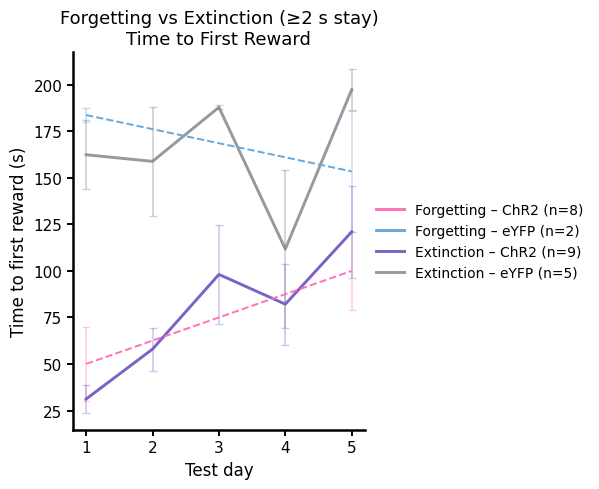

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Restrict to TEST trials, desired genotypes, and NOT short_duration ----
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1) &
    (metadata['t_to_trigger'].notna())
].copy()

max_day = 5
day_values = np.arange(1, max_day + 1)


# ---- 2. Build subject × test-day matrix (TIME TO FIRST REWARD) ----
def build_subject_matrix(meta_group):
    """
    For each subject, compute mean time-to-first-reward (t_to_trigger)
    for each test day (trial_type_day = 1..5).
    Returns matrix: n_subjects x max_day (values in ms).
    """
    performance_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        m = meta_group[meta_group['sub'] == sub]

        # average per test day for this subject
        mean_d = m.groupby('trial_type_day')['t_to_trigger'].mean()

        vec = np.full(max_day, np.nan)
        for i, d in enumerate(day_values):
            if d in mean_d.index:
                vec[i] = mean_d.loc[d]

        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects


def mean_and_sem(mat):
    """
    Robust mean/SEM:
    - returns NaN for days where all animals are NaN
    - avoids RuntimeWarnings from nanmean / nanstd
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem  = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)

    return mean, sem


# ---- 3. Split by genotype × test_type ----
meta_ChR2 = meta_T[meta_T['genotype'] == 'ChR2']
meta_YFP  = meta_T[meta_T['genotype'] == 'eYFP_ChR2']

# forgetting
perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'forgetting']
)
perf_f_YFP,  subs_f_YFP  = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'forgetting']
)

# extinction
perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'extinction']
)
perf_e_YFP,  subs_e_YFP  = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'extinction']
)


# ---- 4. Plot TIME TO FIRST REWARD ----
plt.figure(figsize=(7.5, 5))

col_f_ChR2 = "#FF72B8"   # pink (forgetting)
col_e_ChR2 = '#7b62c5ff'   # pastel purple (extinction)
col_f_YFP  = "#65a8deff"
col_e_YFP  = "#76787EC1"


def plot_group(mat, color, label):
    """
    Plot mean ± faded SEM for one group.
    mat is in ms → convert to s when plotting.
    """
    if mat is None or mat.size == 0:
        return
    mean_ms, sem_ms = mean_and_sem(mat)
    if mean_ms is None:
        return

    mean = mean_ms / 1000.0
    sem  = sem_ms / 1000.0

    # mean line
    plt.plot(
        day_values, mean,
        '-', color=color,
        linewidth=2.1,
        label=label
    )

    # faded SEM
    plt.errorbar(
        day_values, mean, yerr=sem,
        fmt='none',
        ecolor=color,
        alpha=0.35,
        elinewidth=1.2,
        capsize=3
    )


def plot_forgetting_trend(mat, color):
    """
    Optional dashed line from Day1 → Day5 for forgetting groups.
    """
    if mat is None or mat.size == 0:
        return
    mean_ms, _ = mean_and_sem(mat)
    if mean_ms is None:
        return

    mean = mean_ms / 1000.0
    if np.isnan(mean[0]) or np.isnan(mean[-1]):
        return

    plt.plot(
        [day_values[0], day_values[-1]],
        [mean[0], mean[-1]],
        '--',
        color=color,
        alpha=1,
        linewidth=1.4
    )


# forgetting
plot_group(perf_f_ChR2, col_f_ChR2, f'Forgetting – ChR2 (n={len(subs_f_ChR2)})')
plot_group(perf_f_YFP,  col_f_YFP,  f'Forgetting – eYFP (n={len(subs_f_YFP)})')

# extinction
plot_group(perf_e_ChR2, col_e_ChR2, f'Extinction – ChR2 (n={len(subs_e_ChR2)})')
plot_group(perf_e_YFP,  col_e_YFP,  f'Extinction – eYFP (n={len(subs_e_YFP)})')

# optional dashed trend for forgetting groups
plot_forgetting_trend(perf_f_ChR2, col_f_ChR2)
plot_forgetting_trend(perf_f_YFP,  col_f_YFP)


# ---- Axes: publication style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('Time to first reward (s)', fontsize=12)
plt.xticks(day_values, [str(d) for d in day_values], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Forgetting vs Extinction (≥2 s stay)\nTime to First Reward', fontsize=13, pad=6)
# (≥2 s stay)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [24]:
# COMPUTE time to arrive for each trigger separately
# ----- COMPUTE TIME TO TRIGGER (ANY) + PER-TRIGGER TIMES -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # only recruit usable trials

# ------------------------------------------------------------------
# OPTION: minimum dwell time in trigger zone (in ms)
#   - 2000 → must stay ≥ 2 s
#   - 0    → any entry counts
# ------------------------------------------------------------------
DWELL_MIN_MS = 0   # <--- change here if you want to relax/tighten criterion

# Define columns in metadata
metadata['t_to_trigger'] = 0        # time to first trigger (any trigger) meeting criterion
metadata['learned']      = False      # ever met criterion in any trigger?

R_TRIGGER = (10/1.2)  # radius defining trigger zone

# store per-trigger times here
trigger_rows = []  # each row: {trial_id, trigger_id, t_to_trigger_trig}

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue

    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i+1
        )
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

        # per-trigger: if we know nothing, set all triggers to trial duration
        for trig_id in range(1, trigger_num + 1):
            trigger_rows.append({
                'trial_id': trial_id,
                'trigger_id': trig_id,
                't_to_trigger_trig': t_to_trigger
            })
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
    
    # ------------------------------------------------------------------
    # Apply dwell-time criterion here ONLY
    # ------------------------------------------------------------------
    if DWELL_MIN_MS > 0:
        df_all_triggers_long = df_all_triggers[df_all_triggers['duration'] >= DWELL_MIN_MS]
    else:
        df_all_triggers_long = df_all_triggers

    # ---- original "first reward anywhere" metric ----
    if len(df_all_triggers_long) == 0:
        # never met criterion in any trigger → use trial duration
        t_to_trigger = position_.iloc[-1]['t']
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True

    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

    # ---- per-trigger times (first entry meeting criterion in each trigger) ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers_long[df_all_triggers_long['trigger_id'] == trig_id]
        if len(df_t) == 0:
            # never met criterion in THIS trigger → use trial duration
            t_trig = position_.iloc[-1]['t']
        else:
            t_trig = df_t.iloc[0]['t_enter']

        trigger_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            't_to_trigger_trig': t_trig
        })

# Build long-format per-trigger DataFrame and attach metadata columns
df_trig = pd.DataFrame(trigger_rows)

meta_trig = df_trig.merge(
    metadata,
    left_on='trial_id',   # integer from the loop
    right_index=True,     # metadata index 0..len-1
    how='left'
)

 15%|█▌        | 712/4609 [00:06<00:35, 109.73it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1186/4609 [00:11<00:30, 111.82it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2614/4609 [00:23<00:12, 159.26it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:39<00:00, 115.74it/s]


Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs:
[np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs:
[np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


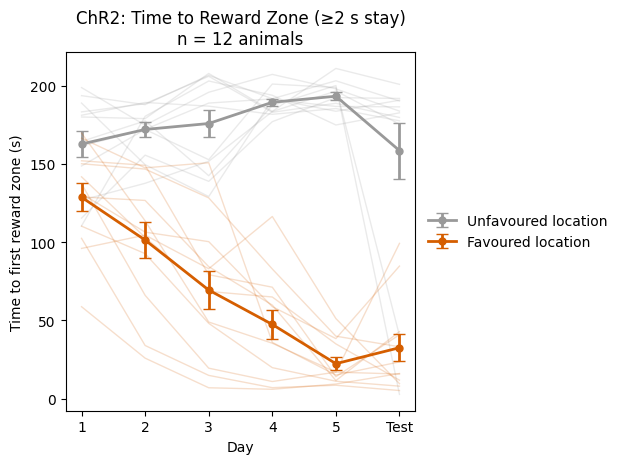

In [ ]:
# PLOT time to arrive for ChR2 group

# PLOT time to arrive for remapping group (L1–L5 + first T on Day 6), 2 reward zones (A, B)

import numpy as np
import matplotlib.pyplot as plt

# ----- FILTER FOR ChR2, L/T, NOT SHORT, AND ASSIGN DAYS -----

mt = meta_trig[
    (metadata['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['L', 'T']))
].copy()

mt['plot_day'] = np.nan

# L days: use trial_type_day (1..5)
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last L session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (trigger_id) -----

def build_zone_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER REWARD ZONE, INDIVIDUAL + MEAN -----

plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

# Paper-style, colorblind-friendly colors
colors = {
    1: '#999999',  # blue
    2: '#D55E00',  # orange
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,   # ms → s
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

        # ---- label at end (Test day) ----
         # plt.text(
          #    x_vals[-1] + 0.05,   # slightly to the right of Day 6
          #    y_vals[-1],
           #   str(sub),
            #  fontsize=7,
            #  color=colors[zid],
           #   alpha=0.7,
           #   va='center'
         # )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )



plt.xlabel('Day')
plt.ylabel('Time to first reward zone (s)')
plt.title(
    #f'ChR2: Time to Reward Zone \n'
     f'ChR2: Time to Reward Zone (≥2 s stay)\n'

    f'n = {n_animals} animals',
    fontsize=12
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

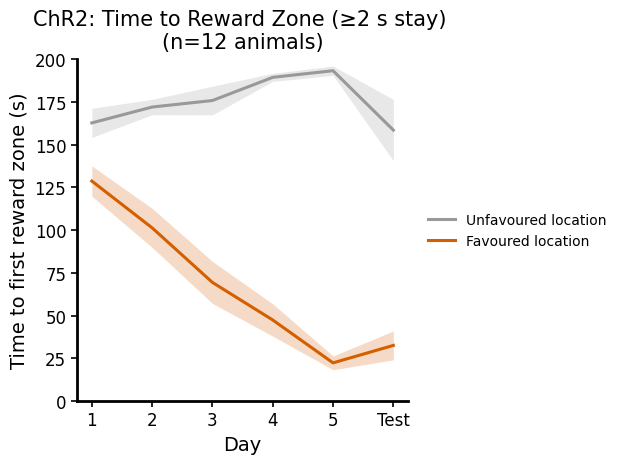

In [267]:
# ----- PLOT: ChR2, PER REWARD ZONE, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(7.5, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM (in seconds)
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[zid],
        alpha=0.22,
        linewidth=0
    )

    # ---- mean line (no individual traces) ----
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[zid],
        linewidth=2.2,
        label=f'{labels[zid]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'ChR2: Time to Reward Zone (≥2 s stay) \n'
    f'(n={n_animals} animals)',
    fontsize=15,
    pad=8
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.ylim(0, 200)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_58553/2320800996.py:51: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(mat,0)


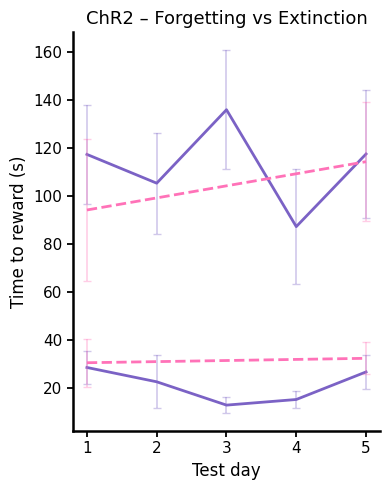

In [14]:
import numpy as np
import matplotlib.pyplot as plt

col_f = "#FF72B8"   # pink (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)

# ------------------------------------------------------------
# Filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction']))
].copy()

max_day = 5
day_values = np.arange(1, max_day+1)

# ------------------------------------------------------------
# helper: subject × day matrix per trigger
# ------------------------------------------------------------
def build_mat(df, trig):
    df = df[df['trigger_id']==trig]
    
    mats = []
    subs = []
    
    for sub in df['sub'].unique():
        ms = df[df['sub']==sub]
        m = ms.groupby('trial_type_day')['t_to_trigger_trig'].mean()
        
        # build 5-day vector (may contain NaNs)
        v = np.array([m.get(d, np.nan) for d in day_values], dtype=float)
        
        # NEW: keep animal if at least 1 valid day
        if np.isnan(v).all():
            continue
        
        mats.append(v)
        subs.append(sub)
    
    if len(mats)==0:
        return None, []
    
    return np.vstack(mats), subs

def mean_sem(mat):
    if mat is None or mat.size==0: return None,None
    mean = np.nanmean(mat,0)
    sem  = np.nanstd(mat,0)/np.sqrt(mat.shape[0])
    return mean, sem

# ------------------------------------------------------------
# Build matrices
# ------------------------------------------------------------
m_f_z1, s_f_z1 = build_mat(meta[meta['test_type']=='forgetting'],1)
m_f_z2, s_f_z2 = build_mat(meta[meta['test_type']=='forgetting'],2)

m_e_z1, s_e_z1 = build_mat(meta[meta['test_type']=='extinction'],1)
m_e_z2, s_e_z2 = build_mat(meta[meta['test_type']=='extinction'],2)

# ------------------------------------------------------------
# Plot single panel
# ------------------------------------------------------------
plt.figure(figsize=(4,5))

# extinction curves full 1-5
for mat,color,label in [(m_e_z1,col_e,'Zone1 extinction'),
                        (m_e_z2,col_e,'Zone2 extinction')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    mean_s = mean_ms/1000; sem_s=sem_ms/1000
    plt.plot(day_values, mean_s, '-', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(day_values, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

# forgetting dashed 1→5
for mat,color,label in [(m_f_z1,col_f,'Zone1 forgetting'),
                        (m_f_z2,col_f,'Zone2 forgetting')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    x = np.array([day_values[0], day_values[-1]])
    mean_s = np.array([mean_ms[0], mean_ms[-1]])/1000
    sem_s  = np.array([sem_ms[0], sem_ms[-1]])/1000
    plt.plot(x, mean_s, '--', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(x, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('Time to reward (s)', fontsize=12)
plt.xticks(day_values, fontsize=11)
plt.yticks(fontsize=11)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.title('ChR2 – Forgetting vs Extinction', fontsize=13, pad=6)
#(>2s stay)

plt.tight_layout()
plt.show()

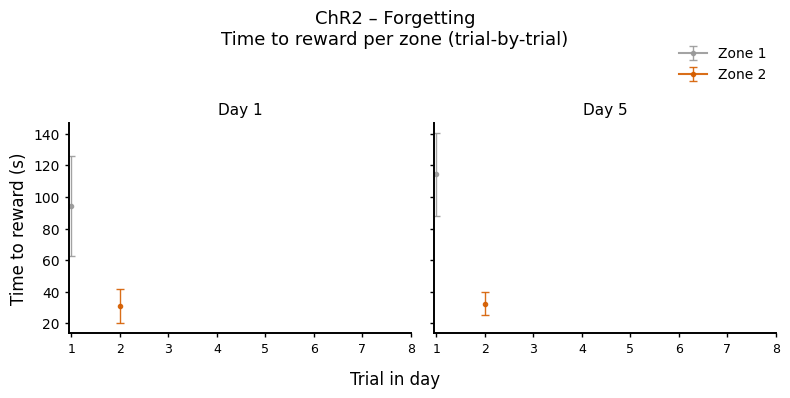

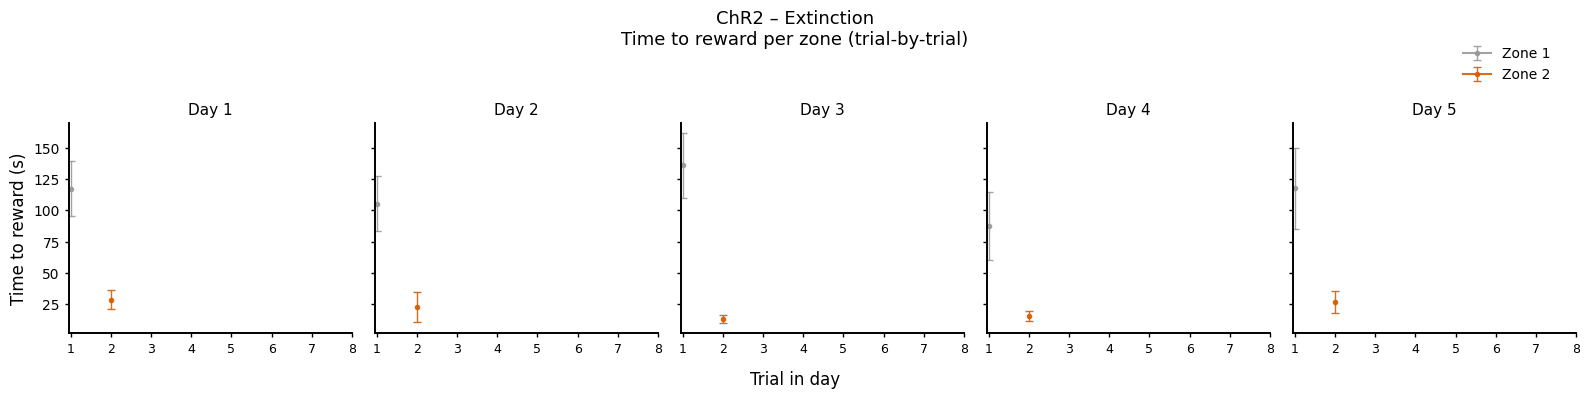

In [ ]:
# revise later - tried to plot for trial to trial progress

# ------------------------------------------------------------
# Base filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting', 'extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

max_day    = 5
day_values = np.arange(1, max_day + 1)
trial_vals = np.arange(1, 9)  # trials 1–8

# ------------------------------------------------------------
# Ensure trial_in_day exists (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta.columns), None)

if trial_col is not None:
    meta['trial_in_day'] = meta[trial_col].astype(int)
else:
    meta = meta.sort_values(['sub', 'ses']).copy()
    meta['trial_in_day'] = meta.groupby(['sub', 'ses']).cumcount() + 1

meta = meta[meta['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# Build mean ± SEM per (day, trial) for each trigger
# ------------------------------------------------------------
def build_day_trial_stats(meta_df, trigger_id):
    """
    For given meta subset (forgetting / extinction) and trigger_id,
    returns:
        stats[day] = (mean_s, sem_s)  # arrays of length = 8 trials
    where units are seconds.
    """
    stats = {}

    df_trig = meta_df[meta_df['trigger_id'] == trigger_id].copy()
    if df_trig.empty:
        return stats

    for day in day_values:
        df_day = df_trig[df_trig['trial_type_day'] == day]
        if df_day.empty:
            continue

        # 1) Average within each animal × trial_in_day
        #    (in case there are multiple T trials per day)
        per_sub_trial = (
            df_day
            .groupby(['sub', 'trial_in_day'])['t_to_trigger_trig']
            .mean()
            .reset_index()
        )

        if per_sub_trial.empty:
            continue

        # 2) Across animals: mean & SEM for each trial_in_day
        g = per_sub_trial.groupby('trial_in_day')['t_to_trigger_trig']
        mean_series = g.mean()
        std_series  = g.std(ddof=1)
        n_series    = g.count()

        mean_ms = np.full(len(trial_vals), np.nan)
        sem_ms  = np.full(len(trial_vals), np.nan)

        for i, t in enumerate(trial_vals):
            if t in mean_series.index:
                mean_ms[i] = mean_series.loc[t]
                n = n_series.loc[t]
                if (n > 1) and not np.isnan(std_series.loc[t]):
                    sem_ms[i] = std_series.loc[t] / np.sqrt(n)

        # store in seconds
        stats[day] = (mean_ms / 1000.0, sem_ms / 1000.0)

    return stats

# ------------------------------------------------------------
# Split forgetting vs extinction and compute stats per zone
# ------------------------------------------------------------
meta_f = meta[meta['test_type'] == 'forgetting'].copy()
meta_e = meta[meta['test_type'] == 'extinction'].copy()

stats_f_z1 = build_day_trial_stats(meta_f, trigger_id=1)
stats_f_z2 = build_day_trial_stats(meta_f, trigger_id=2)

stats_e_z1 = build_day_trial_stats(meta_e, trigger_id=1)
stats_e_z2 = build_day_trial_stats(meta_e, trigger_id=2)

colors = {
    1: '#999999',  # Zone 1 (grey)
    2: '#D55E00',  # Zone 2 (orange)
}

# ============================================================
# FIGURE 1 – FORGETTING: ONLY DAY 1 AND DAY 5
# ============================================================
forget_days = [1, 5]
fig_f, axes_f = plt.subplots(1, len(forget_days), figsize=(8, 3.5), sharey=True)

if len(forget_days) == 1:
    axes_f = [axes_f]

for ax, day in zip(axes_f, forget_days):
    # Zone 1
    if day in stats_f_z1:
        mean_s, sem_s = stats_f_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_f_z2:
        mean_s, sem_s = stats_f_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    # NN-style axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_f[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_f.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_f[0].get_legend_handles_labels()
if handles:
    fig_f.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_f.suptitle('ChR2 – Forgetting\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

# ============================================================
# FIGURE 2 – EXTINCTION: DAYS 1–5
# ============================================================
ext_days = day_values
fig_e, axes_e = plt.subplots(1, len(ext_days), figsize=(16, 3.5), sharey=True)

if len(ext_days) == 1:
    axes_e = [axes_e]

for ax, day in zip(axes_e, ext_days):
    # Zone 1
    if day in stats_e_z1:
        mean_s, sem_s = stats_e_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_e_z2:
        mean_s, sem_s = stats_e_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_e[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_e.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_e[0].get_legend_handles_labels()
if handles:
    fig_e.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_e.suptitle('ChR2 – Extinction\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

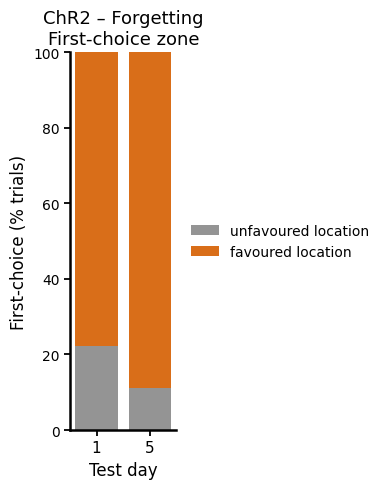

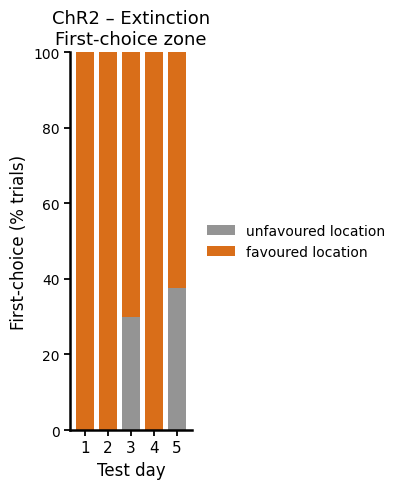

In [ ]:

# ============================================================
# Fade setting (0=transparent, 1=opaque)
# ============================================================
alpha = 0.9   # <-- adjust here

# ============================================================
# Base filter for first-choice analysis
# ============================================================
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

colors = {
    1: '#888888',   # zone 1 (unfavoured)
    2: '#D55E00',   # zone 2 (favoured)
}
labels = {
    1: 'unfavoured location',
    2: 'favoured location',
}

# ------------------------------------------------------------
# Helper: compute first-choice proportions
# ------------------------------------------------------------
def first_choice_props(mt_sub, day_vals):
    mt_sub = mt_sub[mt_sub['trial_type_day'].isin(day_vals)].copy()

    idx_first = mt_sub.groupby('trial_id')['t_to_trigger_trig'].idxmin()
    tmp = mt_sub.loc[idx_first].copy()

    total_trials = (
        tmp.groupby('trial_type_day').size()
           .reindex(day_vals, fill_value=0)
    )

    counts = (
        tmp.groupby(['trial_type_day','trigger_id']).size()
            .unstack('trigger_id')
            .reindex(index=day_vals, fill_value=0)
    )

    for zid in [1,2]:
        if zid not in counts.columns:
            counts[zid] = 0

    counts = counts[[1,2]]

    props = counts.div(total_trials.replace(0,np.nan),axis=0).fillna(0)*100

    return props, total_trials, counts


# ------------------------------------------------------------
# FIGURE 1 — FORGETTING: Days 1 & 5
# ------------------------------------------------------------
days_forget = [1,5]
mt_forget = mt[mt['test_type']=='forgetting']

props_f, total_f, counts_f = first_choice_props(mt_forget, days_forget)

plt.figure(figsize=(5,5))
x = np.arange(len(days_forget))
bottom = np.zeros(len(days_forget))

for zid in [1,2]:
    vals = props_f[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_forget],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Forgetting\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()


# ------------------------------------------------------------
# FIGURE 2 — EXTINCTION: Days 1–5
# ------------------------------------------------------------
days_ext = [1,2,3,4,5]
mt_ext = mt[mt['test_type']=='extinction']

props_e, total_e, counts_e = first_choice_props(mt_ext, days_ext)

plt.figure(figsize=(5.2,5))
x = np.arange(len(days_ext))
bottom = np.zeros(len(days_ext))

for zid in [1,2]:
    vals = props_e[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_ext],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Extinction\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


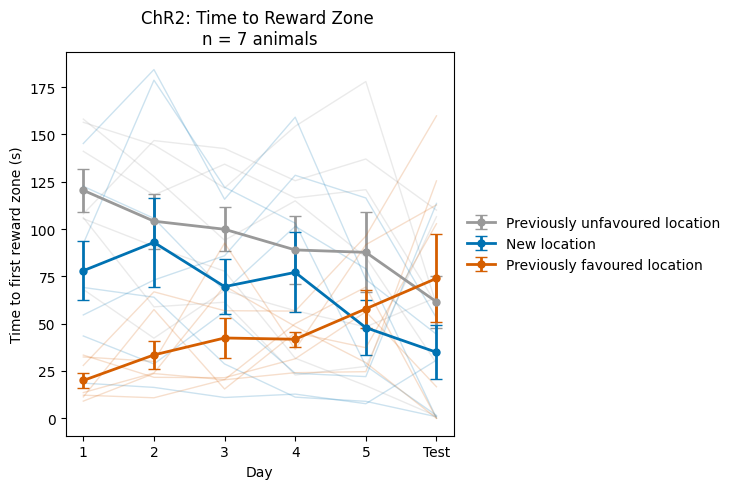

In [347]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, INDIVIDUAL + MEAN -----

plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly, “paper” style colors (similar to ggplot2 palette)
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location (highlighted)
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,                # ms → s
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward zone (s)')
plt.title(
    f'ChR2: Time to Reward Zone \n'
    f'n = {n_animals} animals',
    fontsize=12
)

#(≥2 s stay)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout()
plt.show()




First-choice analysis summary (RL/T)

Total trials per day:
  Day 1: 56 trials
  Day 2: 56 trials
  Day 3: 56 trials
  Day 4: 56 trials
  Day 5: 56 trials
  Day 6: 7 trials

Trials choosing each trigger zone (raw counts):
  Day 1:  Zone1=2, Zone2=5, Zone3=49
  Day 2:  Zone1=5, Zone2=14, Zone3=37
  Day 3:  Zone1=11, Zone2=19, Zone3=26
  Day 4:  Zone1=12, Zone2=21, Zone3=23
  Day 5:  Zone1=11, Zone2=34, Zone3=11
  Day 6:  Zone1=1, Zone2=4, Zone3=2

Proportions (% of trials):
  Day 1:  Zone1=3.6%, Zone2=8.9%, Zone3=87.5%
  Day 2:  Zone1=8.9%, Zone2=25.0%, Zone3=66.1%
  Day 3:  Zone1=19.6%, Zone2=33.9%, Zone3=46.4%
  Day 4:  Zone1=21.4%, Zone2=37.5%, Zone3=41.1%
  Day 5:  Zone1=19.6%, Zone2=60.7%, Zone3=19.6%
  Day 6:  Zone1=14.3%, Zone2=57.1%, Zone3=28.6%



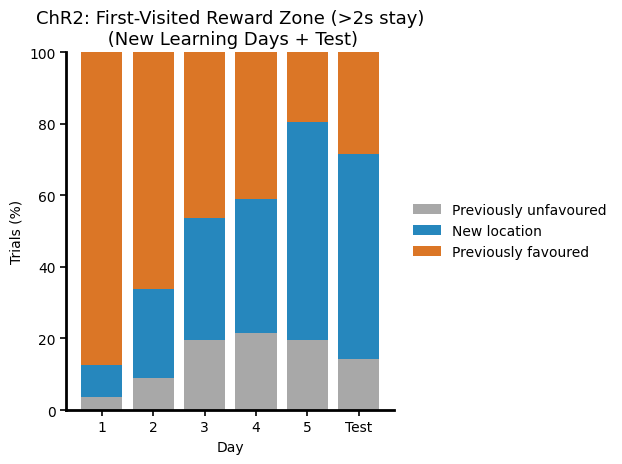

In [386]:

# ------------------------------------------------------------
# Filter: ChR2, RL/T, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5, T = 6
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign T=6 after last RL per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]

# ------------------------------------------------------------
# First-choice counting
# ------------------------------------------------------------
mt_use = mt.copy()

# Determine first trigger per trial
idx_first = mt_use.groupby('trial_id')['t_to_trigger_trig'].idxmin()
first_choice = mt_use.loc[idx_first].copy()

# Count per day × trigger
counts = (
    first_choice
    .groupby(['plot_day', 'trigger_id'])
    .size()
    .unstack('trigger_id')
    .reindex(index=plot_days, fill_value=0)
    .reindex(columns=[1, 2, 3], fill_value=0)
)

# Total trials per day
total_trials = (
    first_choice.groupby('plot_day').size()
    .reindex(plot_days, fill_value=0)
)

# Proportions
proportions = counts.div(total_trials.replace(0, np.nan), axis=0)
proportions = proportions.fillna(0)

print("====================================")
print("First-choice analysis summary (RL/T)")
print("====================================")

print("\nTotal trials per day:")
for d in plot_days:
    print(f"  Day {d}: {total_trials.loc[d]} trials")

print("\nTrials choosing each trigger zone (raw counts):")
for d in plot_days:
    row = counts.loc[d]
    print(f"  Day {d}:  Zone1={row.get(1,0)}, Zone2={row.get(2,0)}, Zone3={row.get(3,0)}")

print("\nProportions (% of trials):")
for d in plot_days:
    row = proportions.loc[d]
    print(f"  Day {d}:  Zone1={row[1]*100:.1f}%, Zone2={row[2]*100:.1f}%, Zone3={row[3]*100:.1f}%")
print("====================================\n")

# ------------------------------------------------------------
# Plot stacked bars
# ------------------------------------------------------------
colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}
labels = {
    1: 'Previously unfavoured',
    2: 'New location',
    3: 'Previously favoured',
}

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(plot_days))
bottom = np.zeros(len(plot_days))

for trig_id in [1, 2, 3]:
    vals = proportions[trig_id].values * 100
    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[trig_id],
        edgecolor='none',
        alpha=0.85, 
        label=labels[trig_id]
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(['1','2','3','4','5','Test'])
ax.set_xlabel('Day')
ax.set_ylabel('Trials (%)')
ax.set_ylim(0, 100)

ax.set_title('ChR2: First-Visited Reward Zone (>2s stay)\n (New Learning Days + Test)', fontsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0,0,0.85,0.95])
plt.show()

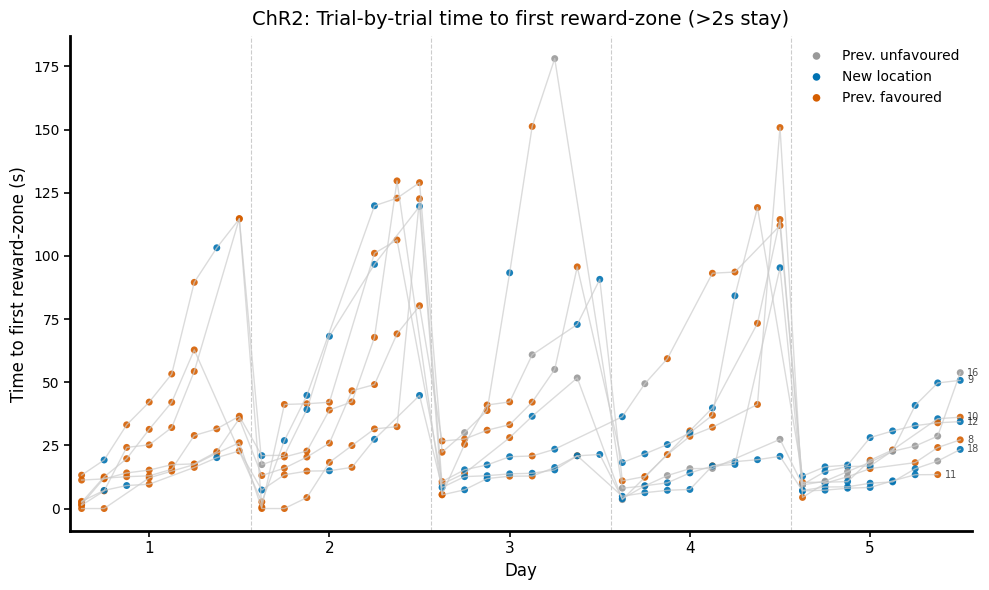

In [ ]:


# ------------------------------------------------------------
# 1) Filter: ChR2, RL/T, usable, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5 from trial_type_day; T = 6 (first T after RL)
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL days 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign test day (6) as first T session after last RL session, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 2) Make sure we have a trial-in-day index (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    # Fallback: infer within each (sub, ses)
    mt = mt.sort_values(['sub', 'ses', 't_to_trigger_trig']).copy()
    mt['trial_in_day'] = mt.groupby(['sub', 'ses']).cumcount() + 1

# Keep trials 1–8
mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) For each trial, find the FIRST reward zone entered
#    (minimum t_to_trigger_trig across trigger_id)
# ------------------------------------------------------------
# We assume 'trial_id' uniquely identifies a trial; if not, you can use
# ['sub','ses','trial_in_day'] as an alternative key.
group_key = 'trial_id'
if group_key not in mt.columns:
    # Fallback key if trial_id is not present
    group_key = ['sub', 'ses', 'trial_in_day']

idx_first = mt.groupby(group_key)['t_to_trigger_trig'].idxmin()
first_choice = mt.loc[idx_first].copy()

# ------------------------------------------------------------
# 4) Build a "global trial index" across days for plotting:
#    trial_idx_global = (plot_day - 1) * 8 + trial_in_day   (1..48)
# ------------------------------------------------------------
first_choice['trial_idx_global'] = (first_choice['plot_day'] - 1) * 8 + first_choice['trial_in_day']

# ---- Remove test day (plot_day = 6) ----
mt_noT = first_choice[first_choice['plot_day'] <= 5].copy()

# ---- Recompute global trial index for only RL days ----
mt_noT['trial_idx_global'] = (mt_noT['plot_day'] - 1) * 8 + mt_noT['trial_in_day']

fig, ax = plt.subplots(figsize=(10, 6))

zone_colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}

zone_labels = {
    1: 'Prev. unfavoured',
    2: 'New location',
    3: 'Prev. favoured',
}

# plot each animal as before
for sub in sorted(mt_noT['sub'].unique()):
    ms = mt_noT[mt_noT['sub'] == sub].sort_values(['plot_day','trial_in_day'])

    x = ms['trial_idx_global'].values
    y = ms['t_to_trigger_trig'].values / 1000.0

    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    for zid in [1,2,3]:
        ms_z = ms[ms['trigger_id']==zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                (ms_z['t_to_trigger_trig'].values)/1000.0,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ---- Cosmetics for 5 RL days only ----
max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day   # 40

# vertical separators
for d in range(1, max_day):
    ax.axvline(d*trials_per_day + 0.5, color='0.8', linestyle='--', linewidth=0.8)

# x tick labels at center of each day block
day_centers = [(d-0.5)*trials_per_day for d in range(1, max_day+1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day+1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Time to first reward-zone (s)', fontsize=12)

# legend
handles = []
labels = []
for zid in [1,2,3]:
    h = ax.scatter([], [], color=zone_colors[zid], s=30, edgecolor='none')
    handles.append(h)
    labels.append(zone_labels[zid])
ax.legend(handles, labels, frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title('ChR2: Trial-by-trial time to first reward-zone (>2s stay)', fontsize=14, pad=8)

plt.tight_layout()
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


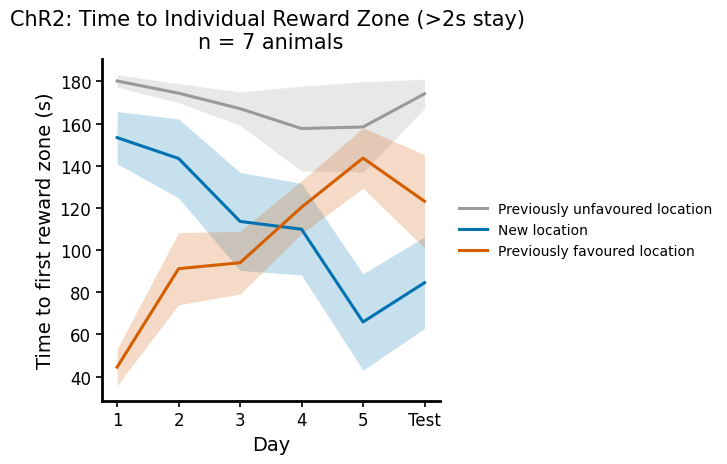

In [388]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(9, 5))

x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Previously unfavoured
    2: '#0072B2',  # New location
    3: '#D55E00',  # Previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM in seconds
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[trig_id],
        alpha=0.22,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[trig_id],
        linewidth=2.2,
        label=f'{labels[trig_id]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'ChR2: Time to Individual Reward Zone (>2s stay) \n'
    f'n = {n_animals} animals',
    fontsize=15,
    pad=8
)
#(≥2 s stay)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.8, 0.95])
plt.show()

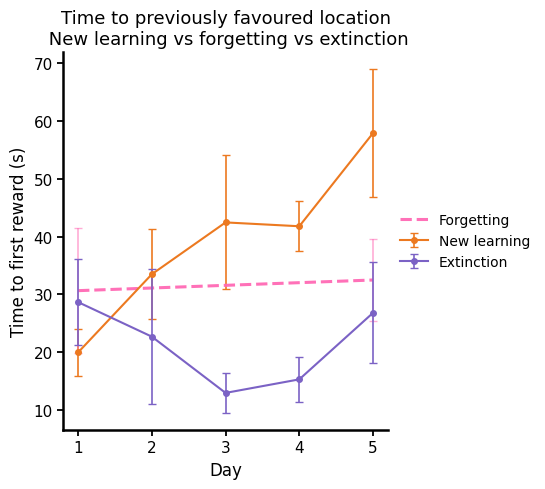

In [25]:

# ============================================================
# 1) RL stage – time to first entry into previously favoured location (trigger 3)
# ============================================================

# Start from your RL/T filter
mt_rl = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL days = 1–5, Test (T) = 6
mt_rl['plot_day'] = np.nan

mask_RL = (mt_rl['trial_type'] == 'RL')
mt_rl.loc[mask_RL, 'plot_day'] = mt_rl.loc[mask_RL, 'trial_type_day']

# keep only RL 1–5 for RL
mt_rl = mt_rl[(~mask_RL) | (mt_rl['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# (We don't really need the T=6 assignment for this analysis, but it won't hurt)
for sub in mt_rl['sub'].unique():
    ms = mt_rl[mt_rl['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T_ses = T_after['ses'].min()
    idx = mt_rl.index[
        (mt_rl['sub'] == sub) &
        (mt_rl['trial_type'] == 'T') &
        (mt_rl['ses'] == first_T_ses)
    ]
    mt_rl.loc[idx, 'plot_day'] = 6

# We only care about RL days 1–5 here
rl_days = np.arange(1, 6)

def rl_fav_stats(mt_rl, trigger_id=3):
    """
    Time to first entry into 'previously favoured' trigger for RL days 1–5.
    Returns mean_s, sem_s (seconds), each length 5.
    """
    df = mt_rl[
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['trial_type'] == 'RL') &
        (mt_rl['plot_day'].isin(rl_days))
    ].copy()

    mean_ms = np.full(len(rl_days), np.nan)
    sem_ms  = np.full(len(rl_days), np.nan)

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d]
        if df_day.empty:
            continue

        # average per animal first, then across animals
        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0  # seconds

mean_rl_s, sem_rl_s = rl_fav_stats(mt_rl, trigger_id=3)


# ============================================================
# 2) Forgetting / extinction – time to first entry into favoured zone (trigger 2)
# ============================================================

# Filter: ChR2, TEST, usable, not short, forgetting/extinction
meta_T = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

test_days = np.arange(1, 6)  # test days 1–5

def build_time_to_zone2(meta_df):
    """
    For a meta_df subset (forgetting or extinction),
    compute time to trigger_id=2 per test day (1–5):

    1) mean per subject per day
    2) mean & SEM across subjects

    Returns mean_s, sem_s (seconds), length 5.
    """
    df = meta_df[meta_df['trigger_id'] == 2].copy()
    mean_ms = np.full(len(test_days), np.nan)
    sem_ms  = np.full(len(test_days), np.nan)

    for i, d in enumerate(test_days):
        df_day = df[df_day['trial_type_day'] == d] if False else df[df['trial_type_day'] == d]  # keep logic clear
        if df_day.empty:
            continue

        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0   # seconds


meta_forg = meta_T[meta_T['test_type'] == 'forgetting'].copy()
meta_ext  = meta_T[meta_T['test_type'] == 'extinction'].copy()

mean_forg_s, sem_forg_s = build_time_to_zone2(meta_forg)
mean_ext_s,  sem_ext_s  = build_time_to_zone2(meta_ext)


# ============================================================
# 3) Combined plot: RL + forgetting/extinction favoured zone
# ============================================================

plt.figure(figsize=(7, 5))

# ---- RL previously favoured location (solid, orange) ----
plt.errorbar(
    rl_days, mean_rl_s, yerr=sem_rl_s,
    fmt='-o',
    color="#EC7920",         # unchanged
    ecolor="#EC7920",
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='New learning'
)

# ---- colours for test trials ----
col_f = '#FF69B4'   # pastel green (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)


# ---- Forgetting (only day 1 & 5, dashed) ----
forget_days = np.array([1, 5])
x_f = forget_days
y_f = np.array([mean_forg_s[0], mean_forg_s[4]])
e_f = np.array([sem_forg_s[0],  sem_forg_s[4]])

plt.plot(
    x_f, y_f,
    '--',
    color=col_f,
    linewidth=2.2,
    alpha=0.95,
    label='Forgetting'
)
plt.errorbar(
    x_f, y_f, yerr=e_f,
    fmt='none',
    ecolor=col_f,
    alpha=0.55,
    capsize=3,
    elinewidth=1.2
)

# ---- Extinction (day 1–5, solid) ----
plt.errorbar(
    test_days, mean_ext_s, yerr=sem_ext_s,
    fmt='-o',
    color=col_e,
    ecolor=col_e,
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='Extinction'
)

# ---- Axes, style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Time to first reward (s)', fontsize=12)
plt.xticks(rl_days, [str(d) for d in rl_days], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Time to previously favoured location\n New learning vs forgetting vs extinction', fontsize=13, pad=6)
#(>2s stay)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

N per group (day 5):
  RL (RL day 5, trig3):          7
  Forgetting (Test day 5, trig2): 8
  Extinction (Test day 5, trig2): 7
RL vs Forg: raw p = 0.152
RL vs Ext: raw p = 0.62
Forg vs Ext: raw p = 0.397

FDR-corrected p-values (Benjamini–Hochberg):
  RL vs Forg: p_FDR = 0.456
  RL vs Ext: p_FDR = 0.62
  Forg vs Ext: p_FDR = 0.595


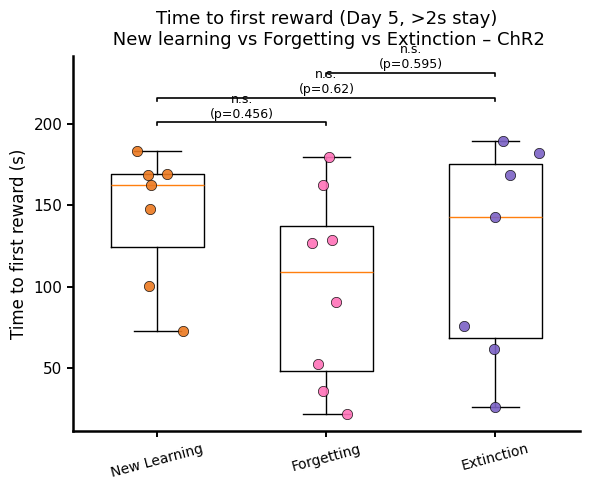

In [23]:

from scipy.stats import mannwhitneyu

# Try to import statsmodels for FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR correction skipped (raw p-values used).")

# ------------------------------------------------------------
# 1) Extract data for the three groups (all ChR2)
#    - RL day 5, trigger_id = 3  (previously favoured)
#    - Forgetting test day 5, trigger_id = 2
#    - Extinction test day 5, trigger_id = 2
#    Using time to trigger per animal (mean across trials)
# ------------------------------------------------------------

# ---- RL day 5 (RL, trig=3, day=5) ----
rl_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'RL') &
    (meta_trig['trigger_id'] == 3) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

rl_per_sub = (
    rl_df.groupby('sub')['t_to_trigger_trig']
         .mean()
         .astype(float)
)
vals_rl = (rl_per_sub.values / 1000.0)  # ms → s

# ---- Forgetting day 5 (T, trig=2, day=5) ----
forg_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'forgetting') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

forg_per_sub = (
    forg_df.groupby('sub')['t_to_trigger_trig']
           .mean()
           .astype(float)
)
vals_forg = (forg_per_sub.values / 1000.0)  # ms → s

# ---- Extinction day 5 (T, trig=2, day=5) ----
ext_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'extinction') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

ext_per_sub = (
    ext_df.groupby('sub')['t_to_trigger_trig']
          .mean()
          .astype(float)
)
vals_ext = (ext_per_sub.values / 1000.0)  # ms → s

print("N per group (day 5):")
print("  RL (RL day 5, trig3):         ", len(vals_rl))
print("  Forgetting (Test day 5, trig2):", len(vals_forg))
print("  Extinction (Test day 5, trig2):", len(vals_ext))

# ------------------------------------------------------------
# 2) Prepare boxplot data
# ------------------------------------------------------------
groups = ["New Learning", "Forgetting", "Extinction"]
data   = [vals_rl, vals_forg, vals_ext]
positions = np.arange(len(groups))

# simple colour scheme (consistent with earlier line plots)
colors = {
    "New Learning":         "#EC7920",  # orange
    "Forgetting": '#FF72B8', # pink
    "Extinction": '#7b62c5ff'   #  purple
}

# ------------------------------------------------------------
# 3) Boxplot + jittered individual points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# plain black boxes, no fliers
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, g in enumerate(groups):
    vals = data[i]
    if len(vals) == 0:
        continue
    jitter = 0.10
    x = np.random.normal(positions[i], jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=55,
        color=colors[g],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Mann–Whitney tests + FDR + significance stars
# ------------------------------------------------------------
def mannwhitney_safe(a, b):
    if (len(a) < 1) or (len(b) < 1):
        return np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

p_raw = []

comparisons = [
    ("RL vs Forg",      0, 1, vals_rl,  vals_forg),
    ("RL vs Ext",       0, 2, vals_rl,  vals_ext),
    ("Forg vs Ext",     1, 2, vals_forg, vals_ext)
]

for name, i1, i2, v1, v2 in comparisons:
    p = mannwhitney_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction (if statsmodels available)
if HAS_SM:
    mask_valid = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask_valid.any():
        rej, p_corr, _, _ = multipletests(p_raw[mask_valid], alpha=0.05, method='fdr_bh')
        p_adj[mask_valid] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p_corr_val in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p_corr_val:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values for annotation (no FDR correction).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# Add significance bars above boxes
all_vals = np.concatenate([v for v in data if len(v) > 0])
y_max = np.nanmax(all_vals)
y_step = 0.08 * y_max  # vertical spacing

# start a bit above max
current_y = y_max * 1.05

for (name, x1, x2, _, _), p in zip(comparisons, p_adj):
    stars = p_to_stars(p)
    # draw only if we have at least a valid p
    if np.isnan(p):
        continue

    # bar
    ax.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.01 * y_max, current_y + 0.01 * y_max, current_y],
        color='k',
        linewidth=1.2
    )
    # text (stars + p)
    ax.text(
        (x1 + x2) / 2,
        current_y + 0.015 * y_max,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # move up for next comparison

# ------------------------------------------------------------
# 5) Axes, labels, style
# ------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Time to first reward (s)', fontsize=12)
ax.set_xlabel('')
ax.set_title('Time to first reward (Day 5, >2s stay)\n New learning vs Forgetting vs Extinction – ChR2', fontsize=13, pad=8)

# Nature-ish style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

Pct time in trigger zone

In [361]:
# Compute pct time in trigger zone


metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
  
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    total_time_in_trigger = df_all_triggers['duration'].sum()

    # Trial duration: max time in this trial (same units as duration)
    trial_duration = position_['t'].max()

    if trial_duration > 0:
        pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    else:
        pct_time_in_trigger = np.nan

    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger


 11%|█▏        | 522/4609 [00:05<00:42, 96.80it/s] 


KeyboardInterrupt: 

In [20]:
# test day plot + rank sum test

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
 #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

#groups = ['ChR2', 'eYFP_ChR2']
groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}


# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group','animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data
data = [meta_animal.loc[meta_animal['group']==g, 'pct_time_in_trigger'].values
        for g in groups]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # keep plain black box
    showfliers=False      # <-- turn off those empty circles
)


# individual animal points
for i, g in enumerate(groups):
    vals = meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    n = len(vals)

    # wider jitter for dense groups
    jitter = 0.12 if n < 6 else 0.12  # adjust if needed

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum test (Mann–Whitney U) + stars
# ------------------------------------------------------------
vals_ch = data[0]  # ChR2
vals_yf = data[1]  # eYFP_ChR2

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax = max(np.nanmax(vals_ch), np.nanmax(vals_yf))
# put the line a bit above the max data point
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between the two boxes (x=0 and x=1)
plt.plot([0, 0, 1, 1], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

# text with stars + p-value
plt.text(0.5, y_star, f"{stars} (p={p:.3g})",
         ha='center', va='bottom', fontsize=11)

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, 45)

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

KeyError: 'pct_time_in_trigger'

ChR2 long animals plotted : 12
ChR2 short animals plotted: 3
eYFP_ChR2 animals plotted : 5
Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = 0.0357


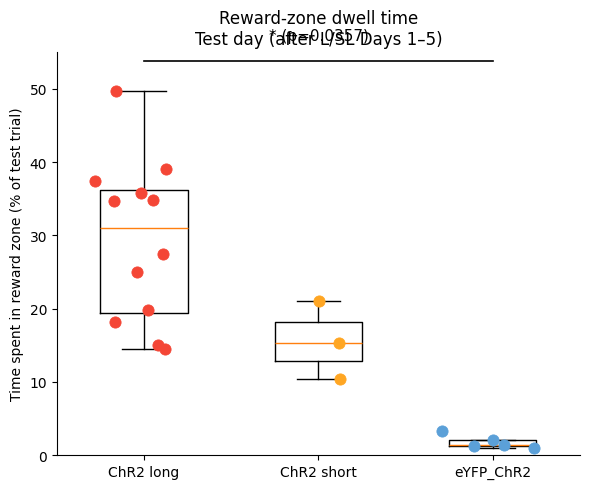

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 0) Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T'])) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['sub'] != 17)
].copy()

plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1) Helper: build subject × day matrix (enforces L/SL days 1–5
#    + FIRST T session AFTER last learning session as day 6)
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) pct_time_in_trigger per day
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # subset by genotype and L/SL + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # assign learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # ----- KEY LINE: first T session AFTER last learning session -----
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2) Build matrices for the three groups
#    Group 1: ChR2 long (L, short_duration=0)
#    Group 2: eYFP_ChR2 (L, any short_duration)
#    Group 3: ChR2 short (SL, short_duration=1)
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted :", len(subs_ChR2_long))
print("ChR2 short animals plotted:", len(subs_ChR2_short))
print("eYFP_ChR2 animals plotted :", len(subs_eYFP))


# ------------------------------------------------------------
# 3) Extract TEST DAY (day 6) values for each animal
#     → matrices are (n_animals x 6), index 5 = test day
# ------------------------------------------------------------
vals_ChR2_long  = mat_ChR2_long[:, 5]   # Day 6
vals_ChR2_short = mat_ChR2_short[:, 5]
vals_eYFP       = mat_eYFP[:, 5]

groups = ['ChR2 long', 'ChR2 short', 'eYFP_ChR2']
data   = [vals_ChR2_long, vals_ChR2_short, vals_eYFP]

colors = {
    'ChR2 long'  : get_genotype_color('ChR2'),
    'ChR2 short' : get_genotype_color('ChR2_short'),
    'eYFP_ChR2'  : get_genotype_color('eYFP_ChR2')
}

# ------------------------------------------------------------
# 4) Plot boxplot + jittered animal points + animal labels
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,
    showfliers=False
)

for i, g in enumerate(groups):
    vals = data[i]
    subs = [subs_ChR2_long, subs_ChR2_short, subs_eYFP][i]   # matching subject lists
    n = len(vals)

    jitter = 0.12
    x = np.random.normal(i, jitter, size=n)

    # plot points
    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )


# ------------------------------------------------------------
# 5) Rank-sum (Mann–Whitney) for ChR2_long vs eYFP_ChR2
#    (line between box 0 and box 2; ChR2_short is box 1)
# ------------------------------------------------------------
vals_ch = vals_ChR2_short
vals_yf = vals_eYFP

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax  = np.nanmax(np.concatenate([vals_ChR2_long, vals_ChR2_short, vals_eYFP]))
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between x=0 (ChR2 long) and x=2 (eYFP_ChR2)
plt.plot([0, 0, 2, 2], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

plt.text(
    1.0, y_star,
    f"{stars} (p={p:.3g})",
    ha='center', va='bottom', fontsize=11
)


# ------------------------------------------------------------
# 6) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups, rotation=0)
plt.ylim(0, 55)

plt.ylabel('Time spent in reward zone (% of test trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day (after L/SL Days 1–5)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

        group  animal  pct_time_in_trigger
0        ChR2       1            29.578657
1        ChR2       3            35.765130
2        ChR2       4            34.803665
3        ChR2       6            19.793126
4        ChR2       7            11.939570
5        ChR2       8            30.509764
6        ChR2       9            25.763918
7        ChR2      10            16.308726
8        ChR2      11            12.028290
9        ChR2      12            23.016142
10       ChR2      16             9.566117
11       ChR2      18            19.745282
12         Hp      40             5.255492
13         Hp      41             4.780728
14         Hp      42             1.849510
15         Hp      43             2.079009
16         Hp      44             2.451215
17         Hp      45             6.376267
18         Hp      46             6.236343
19  eYFP_ChR2      19             2.327057
20  eYFP_ChR2      20             2.105439
21  eYFP_ChR2      21             0.701039
22  eYFP_Ch

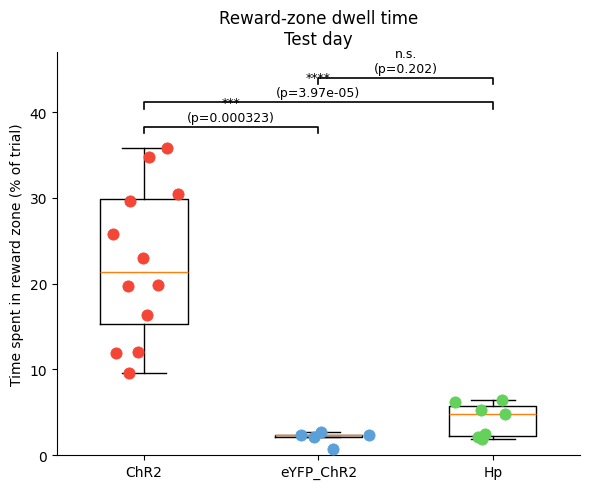

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only (now incl. Hp)
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}

# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group', 'animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data in group order
data = [
    meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    for g in groups
]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # plain black box
    showfliers=False      # no empty circles
)

# individual animal points
for i, g in enumerate(groups):
    vals = data[i]
    n = len(vals)

    if n == 0:
        continue

    jitter = 0.12 if n < 6 else 0.12

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum tests (Mann–Whitney U) + stars for all pairs
# ------------------------------------------------------------
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

# all pairs: (ChR2 vs eYFP), (ChR2 vs Hp), (eYFP vs Hp)
pairs = [(0, 1), (0, 2), (1, 2)]

# base height for annotations
all_vals = np.concatenate([d for d in data if len(d) > 0])
ymax = np.nanmax(all_vals)
y_step = ymax * 0.08
current_y = ymax * 1.05

for (i, j) in pairs:
    vals_i = data[i]
    vals_j = data[j]

    # skip if any group empty
    if len(vals_i) == 0 or len(vals_j) == 0:
        continue

    stat, p = mannwhitneyu(vals_i, vals_j, alternative='two-sided')
    print(f"{groups[i]} vs {groups[j]}: Mann–Whitney U p = {p:.3g}")

    stars = p_to_stars(p)

    x1, x2 = i, j
    x_mid = (x1 + x2) / 2.0

    # bracket line
    plt.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.02*ymax, current_y + 0.02*ymax, current_y],
        color='black',
        linewidth=1.2
    )

    # text (stars + p)
    plt.text(
        x_mid,
        current_y + 0.03*ymax,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # stack brackets upward

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, max(45, current_y + y_step * 0.3))

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

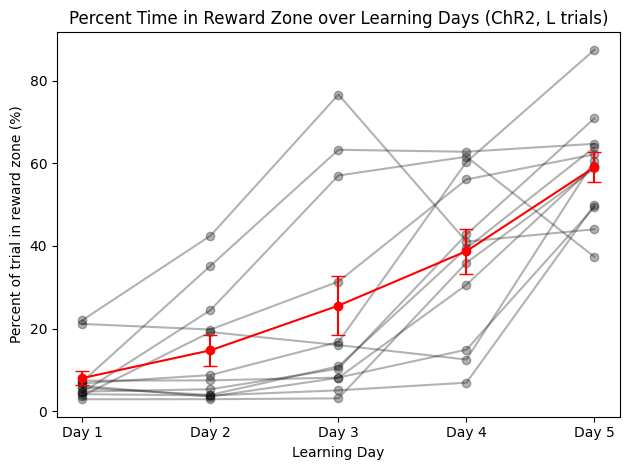

In [73]:
# Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean % time in trigger zone per training day
    mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
    mean_pct_by_day = mean_pct_by_day.sort_index()

    # Expect 5 days; skip incomplete animals
    if len(mean_pct_by_day) != 5:
        continue

    performance_mat.append(mean_pct_by_day.values)

    # Individual subject traces (thin black)
    plt.plot(range(5), mean_pct_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM
performance_mat = np.vstack(performance_mat)
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

plt.errorbar(
    range(5),
    mean_performance,
    yerr=sem_performance,
    fmt='-o',
    color='r',
    capsize=5
)

plt.xlabel('Learning Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


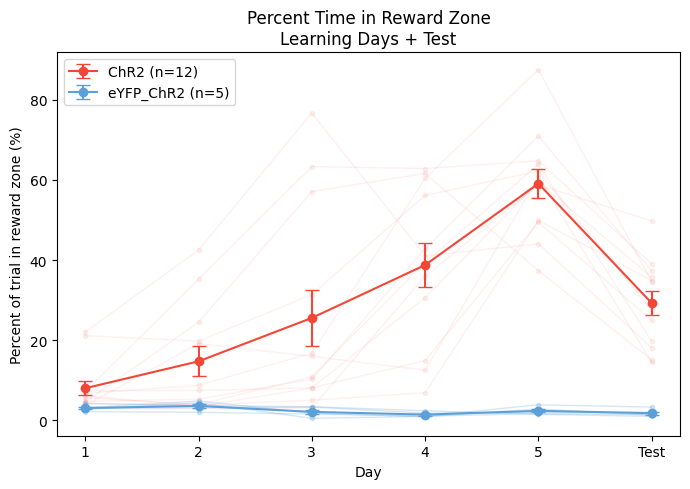

In [128]:
# plot ChR2 & eYFP_ChR2 learning trials + first test day (by session) after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2
if mat_ChR2 is not None:
    col_c = get_genotype_color('ChR2')

    # individual traces
    for row in mat_ChR2:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_c,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c, yerr=sem_c,
        fmt='-o',
        color=col_c,
        capsize=5,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# eYFP_ChR2
if mat_eYFP is not None:
    col_y = get_genotype_color('eYFP_ChR2')

    # individual traces
    for row in mat_eYFP:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_y,
            alpha=0.25,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y, yerr=sem_y,
        fmt='-o',
        color=col_y,
        capsize=5,
        label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

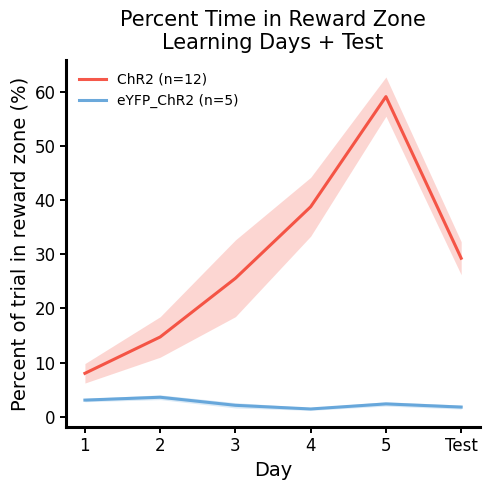

In [127]:
# ---------------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, journal-style
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) values of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individual traces)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- plot both groups using your color function ---
plot_group_shaded(
    mat_ChR2,
    subs_ChR2,
    genotype_key='ChR2',
    label='ChR2'
)

plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2'
)

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5
  Hp: 7


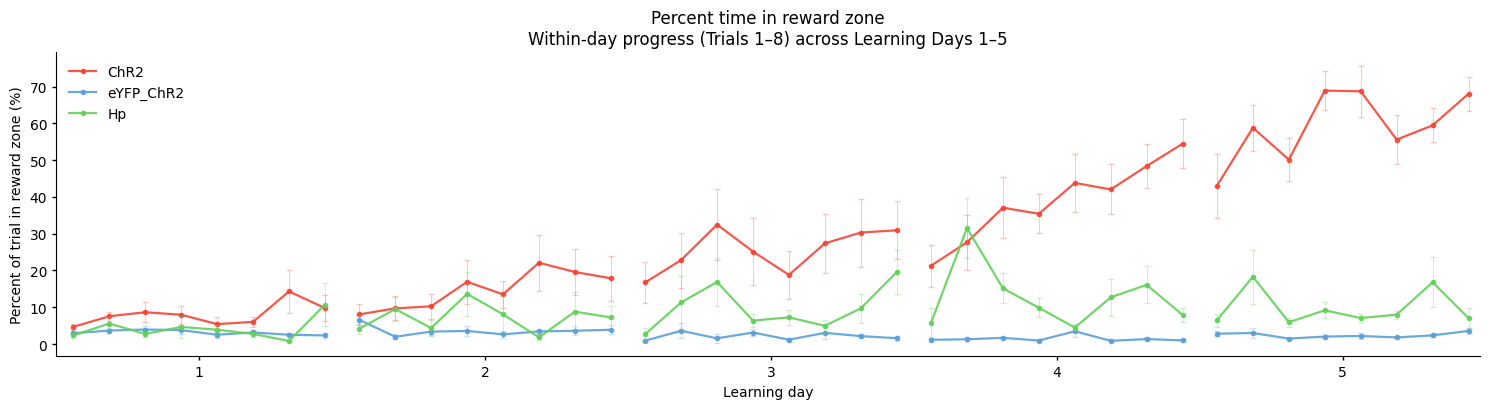

In [ ]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_time_in_trigger (% of trial in reward zone)
# Groups: ChR2 vs eYFP_ChR2  (others available via comments)
# ============================================================

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &  ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    # (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['pct_time_in_trigger'].notna())
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_time_in_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials])
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves using color function
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key, label=None, alpha=1.0):
    """
    genotype_key: key for get_genotype_color, e.g.
                  'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp', ...
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # for showing legend label once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # ---- mean line ----
        ax.plot(
            x, mean_,
            'o-',
            color=col,
            alpha=alpha,
            linewidth=1.6,
            markersize=3,
            label=label if first_day and (label is not None) else None
        )

        # ---- SEM bars (faded) ----
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=col,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

        first_day = False

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype (all options kept)
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
# meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
# meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
# meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# if plotting for short duration:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()
#
# meta_eYFP_L = meta_L[
#     (meta_L['genotype'] == 'eYFP_ChR2') &
#     (meta_L['trial_type'] == 'L')
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())
# print("  ChR2 long:", meta_ChR2_long['sub'].nunique())
# print("  ChR2 short:", meta_ChR2_short['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day labels under each day's curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha=0.9
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha=0.9
)

# other groups, ready to use when you want:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha=0.7
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha=0.9
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5


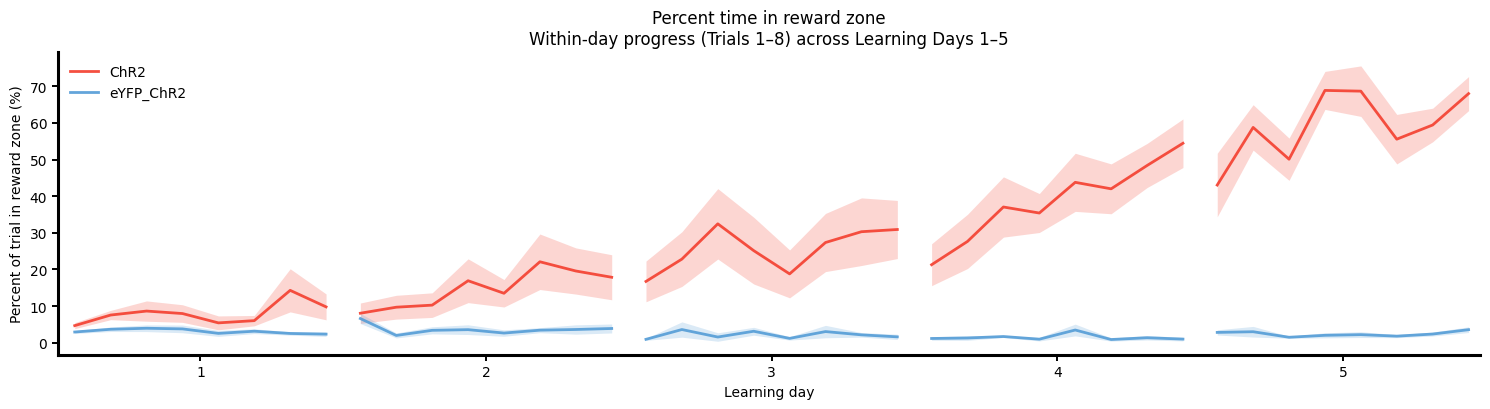

In [134]:
# ------------------------------------------------------------
# 4) Plot helper: within-day curves with shaded SEM
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key,
                           label=None,
                           alpha_fill=0.22,
                           alpha_line=0.9):
    """
    meta_g:   subset of metadata for a given group
    genotype_key: key for get_genotype_color, e.g. 'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp'
    label:    legend label (shown once per group)
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # to only add legend entry once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # shaded SEM band
        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=alpha_fill,
            linewidth=0
        )

        # mean line (no markers)
        ax.plot(
            x, mean_,
            '-',
            color=col,
            alpha=alpha_line,
            linewidth=2.0,
            label=label if first_day and (label is not None) else None
        )

        first_day = False


# ------------------------------------------------------------
# 5) Nature-style axes (thicker frame)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)

    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


# ------------------------------------------------------------
# 6) Split by genotype
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
#meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# If plotting long vs short separately later:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())


# ------------------------------------------------------------
# 7) Plot (mean curves + shaded SEM)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main two groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

# If you later want Hp:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

# If you later want ChR2 long vs ChR2_short:
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha_fill=0.18,
#     alpha_line=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each day's cluster
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curves are visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 10
ChR2 animals plotted: 10
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


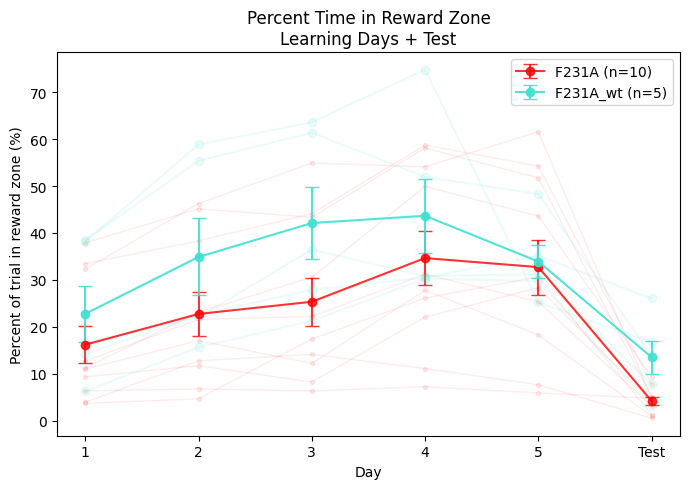

In [48]:
# plot f231a vs wt learning trials + first test day (by session) after learning


# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2: red
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(x_vals, row, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(x_vals, mean_c, yerr=sem_c, fmt='-o', color='red', alpha=0.8,
                 capsize=5, label=f'F231A (n={len(subs_ChR2)})')

# eYFP_ChR2: turquoise
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(x_vals, row, '-o', color='turquoise', alpha=0.1, label='_nolegend_')
    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(x_vals, mean_y, yerr=sem_y, fmt='-o', color='turquoise', alpha=0.90,
                 capsize=5, label=f'F231A_wt (n={len(subs_eYFP)})')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

ChR2 long (short_duration=0) animals in data: 12
ChR2 long animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
ChR2 short (short_duration=1) animals in data: 4
ChR2 short animals plotted: 4


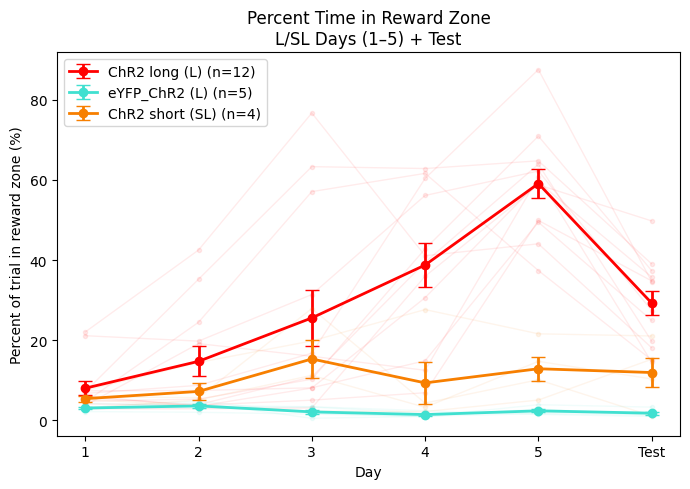

In [160]:
# =============================================================
# Build subject × day performance matrices for 3 groups:
# percent time in trigger zone over learning days + test

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1. Helper to build subject × day matrix for a group
#    learning_type: 'L' or 'SL'
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning trials)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # genotype + (learning_type or T)
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # use 'ses' to find first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration == 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: ChR2, short_duration == 1, learning_type = 'SL'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 long animals plotted:", len(subs_ChR2_long))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("ChR2 short (short_duration=1) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 1)]['sub'].nunique())
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # faded individual traces
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )
    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o', color=color,
        capsize=5,
        linewidth=2,
        markersize=6,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 long – red
plot_group(mat_ChR2_long, subs_ChR2_long, color='red', label='ChR2 long (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: ChR2 short – orange
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nL/SL Days (1–5) + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

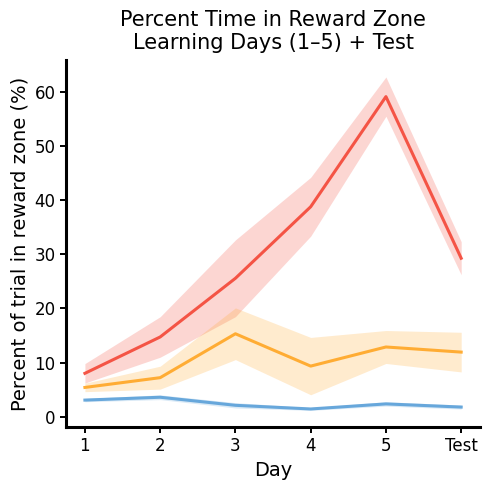

In [164]:
# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, using colour function
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) matrix of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'ChR2_short')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces, no dots)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Group 1: ChR2 long – use 'ChR2' colour
plot_group_shaded(
    mat_ChR2_long,
    subs_ChR2_long,
    genotype_key='ChR2',
    label='ChR2 long (L)'
)

# Group 2: eYFP_ChR2 – use 'eYFP_ChR2' colour
plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2 (L)'
)

# Group 3: ChR2 short – use 'ChR2_short' colour
plot_group_shaded(
    mat_ChR2_short,
    subs_ChR2_short,
    genotype_key='ChR2_short',
    label='ChR2 short (SL)'
)


# ------------------------------------------------------------
# Axes + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days (1–5) + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

# plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in data: 12
ChR2 animals plotted: 12
eYFP animals in data: 5
eYFP animals plotted: 5
Hp animals in data: 7
Hp animals plotted: 7


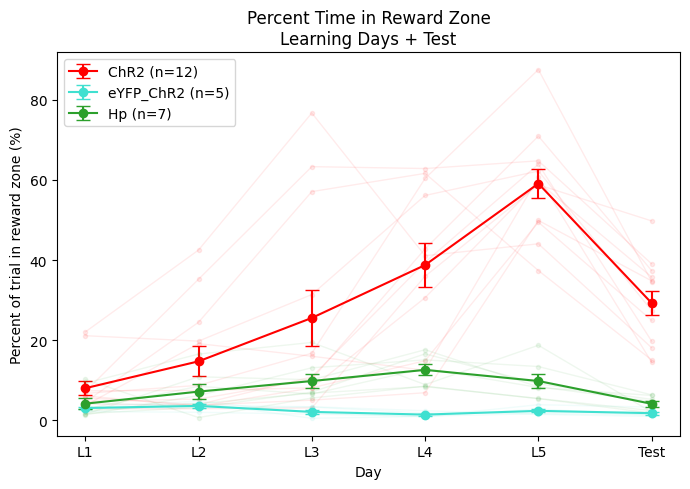

In [165]:
# plot ChR2 & eYFP_ChR2 & Hp learning trials + test after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable animals, 3 genotypes, L or T trials
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create plot_day:
# - L trials → trial_type_day 1–5
# - T trials → set later to day 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']


# ---------------------------------------------------------------------
# 1b. Assign the first T *session* after the last L session to plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6


plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test session


# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs
    Only keeps animals with complete 1–6 days.
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue   # require complete 6 days

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ---------------------------------------------------------------------
# 3. Build matrices for the three groups
# ---------------------------------------------------------------------
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp)

print("ChR2 animals in data:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP animals in data:", meta_eYFP['sub'].nunique())
print("eYFP animals plotted:", len(subs_eYFP))
print("Hp animals in data:", meta_Hp['sub'].nunique())
print("Hp animals plotted:", len(subs_Hp))


# ---------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # individual traces
    for row in mat:
        plt.plot(x_vals, row, '-o', color=color, alpha=0.08, linewidth=1, markersize=3,label='_nolegend_')

    # group mean ± sem
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_, fmt='-o', color=color,
        capsize=5, label=f'{label} (n={len(subs)})'
    )


# Plot groups
plot_group(mat_ChR2, subs_ChR2, color='red',     label='ChR2')
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2')
plot_group(mat_Hp,   subs_Hp,   color='#2ca02c', label='Hp')


plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['L1','L2','L3','L4','L5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

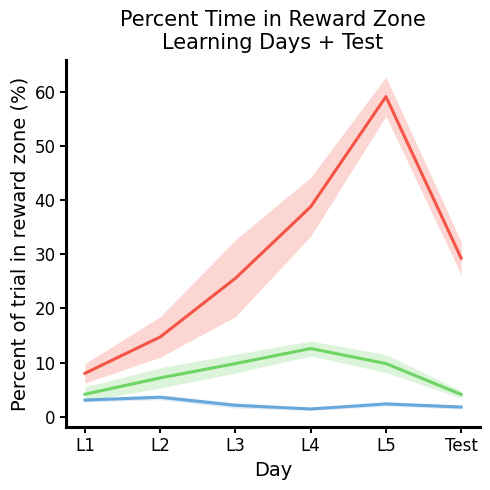

In [167]:
# ---------------------------------------------------------------------
# 4. Plot: mean ± shaded SEM, colour function, no individual traces
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'Hp')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individuals)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Plot groups with your colour scheme
plot_group_shaded(mat_ChR2, subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  genotype_key='Hp',
                  label='Hp')

# Axis labels, ticks, style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['L1', 'L2', 'L3', 'L4', 'L5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Compute percentage of time spent in reward zone for REMAPPING group


In [137]:
# ----- COMPUTE PERCENT TIME IN TRIGGER ZONE (PER TRIGGER) -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone (like your example)
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

pct_rows = []  # will hold per-trigger rows: trial_id, trigger_id, pct_in_trigger_trig

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Trial duration (same units as df_trigger_interaction['duration'])
    trial_duration = position_['t'].max()
    if trial_duration <= 0:
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    # ---- ANY trigger, like your original code ----
    total_time_in_trigger = df_all_triggers['duration'].sum()
    pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger

    # ---- PER TRIGGER: same logic, but restricted to each trigger_id ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
        if len(df_t) == 0:
            pct_trig = 0.0   # spent 0% of time in this trigger
        else:
            total_t_trig = df_t['duration'].sum()
            pct_trig = 100.0 * total_t_trig / trial_duration

        pct_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'pct_in_trigger_trig': pct_trig
        })

# Long-format per-trigger table + metadata
df_pct = pd.DataFrame(pct_rows)
meta_pct = df_pct.merge(metadata, left_on='trial_id', right_index=True, how='left')

 15%|█▌        | 705/4611 [00:07<00:42, 91.59it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1180/4611 [00:12<00:35, 95.80it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2608/4611 [00:25<00:14, 141.90it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:44<00:00, 104.73it/s]


Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


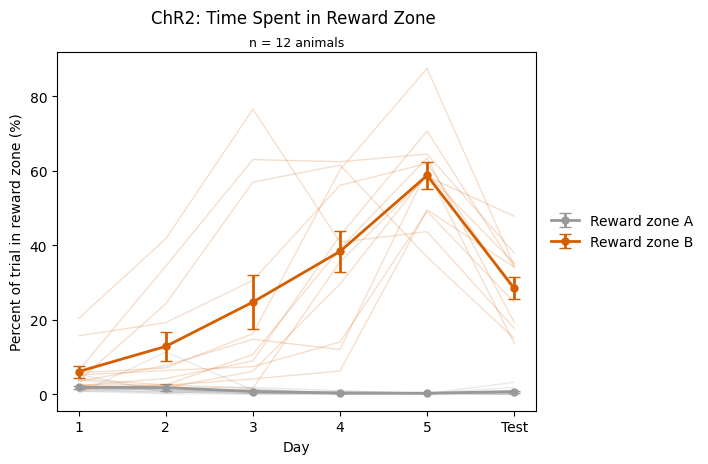

In [138]:
# ----- FILTER: ChR2, L/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['L', 'T']))
].copy()

# L days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L trials
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (PERCENT TIME) -----

def build_zone_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix_pct(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Paper-style colors for A/B
colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # individual animals (faded) + ID labels at end
    for row, sub in zip(mat, subs):
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )


    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)
ax.text(
    0.5, 1.01,
    f'n = {n_animals} animals',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

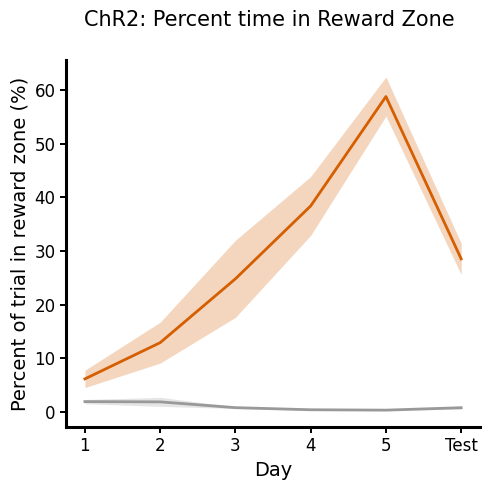

In [146]:
# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1   # 0..5 index for days 1–6

colors = {
    1: '#999999',  # zone A
    2: '#D55E00',  # zone B
}
#labels = {
#    1: 'Reward zone A',
#    2: 'Reward zone B',
#}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[zid]

    # ---- shaded SEM ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[zid]} (n={len(subs)})"
    )

# ----- axis + styling -----
ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1','2','3','4','5','Test'],
    fontsize=12
)

plt.yticks(fontsize=12)

# thick bottom/left, hide top/right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent time in Reward Zone \n', fontsize=15, pad=8)

# small n info
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included per reward zone:
  Reward zone 1: 12 animals
  Reward zone 2: 12 animals

Total unique animals included (any zone): 12
Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]


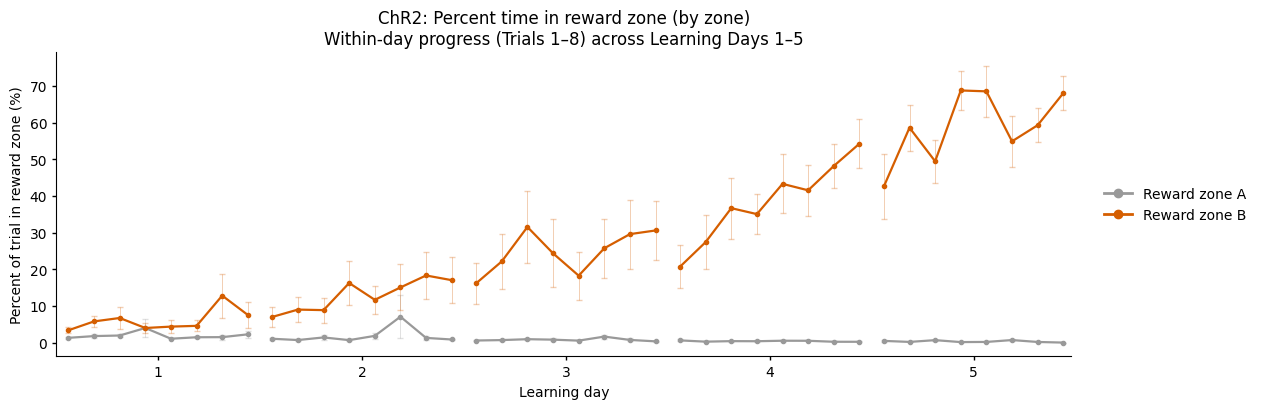

In [139]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_in_trigger_trig (% of trial in reward zone)
# Group: ChR2 only
# Separate curves for trigger_id 1 and 2 (Reward zone A/B)
# Notes:
#   - excludes short_duration == 1
#   - allows missing trials within a day (curve uses available points)
#   - no individual background traces (mean ± SEM only)
# ============================================================

# ----------------------------
# SETTINGS
# ----------------------------
days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)
zone_ids = [1, 2]

colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

# ------------------------------------------------------------
# 1) Filter meta_pct: ChR2, L only, days 1–5, NOT short
# ------------------------------------------------------------
meta_L = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'L') &
    (meta_pct['trial_type_day'].isin(days)) &
    (meta_pct['trigger_id'].isin(zone_ids)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 based on UNIQUE TRIALS (not rows)
#    so trigger A and B share the same trial number
# ------------------------------------------------------------

# Use a stable per-trial key
if 'trial_id' not in meta_L.columns:
    # fallback: if you don't have trial_id, use the index as trial id
    meta_L = meta_L.reset_index().rename(columns={'index': 'trial_id'})

# Build a per-trial table (one row per real trial)
trial_table = (
    meta_L[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

# Assign trial numbers within each session (or within each day — see note below)
trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1

# Keep only trials 1..8
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

# Merge back so BOTH triggers get the SAME trial_in_day
meta_L = meta_L.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day AND zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id):
    md = meta_g[(meta_g['trial_type_day'] == day) & (meta_g['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, meta_g, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        meta_L,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Center ticks under each day curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Make sure day 5 curve fully visible and reduce left whitespace
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'ChR2: Percent time in reward zone (by zone)\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='#999999', lw=2, marker='o', label='Reward zone A'),
    Line2D([0], [0], color='#D55E00', lw=2, marker='o', label='Reward zone B'),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Animal counts (based on *this* filtered dataset)
# ------------------------------------------------------------
subs_zone = {
    zid: sorted(meta_L.loc[meta_L['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}

print("Animals included per reward zone:")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


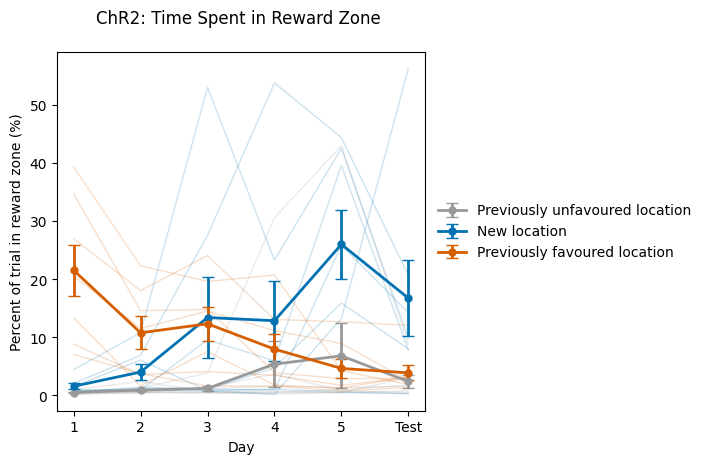

In [155]:
# ----- FILTER: ChR2, RL/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T']))
].copy()

# RL days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 for RL trials
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last RL session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER (PERCENT TIME) -----

def build_trigger_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean % time per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix_pct(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row,                      # already in %
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

# Main title + smaller n-line
plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)


plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


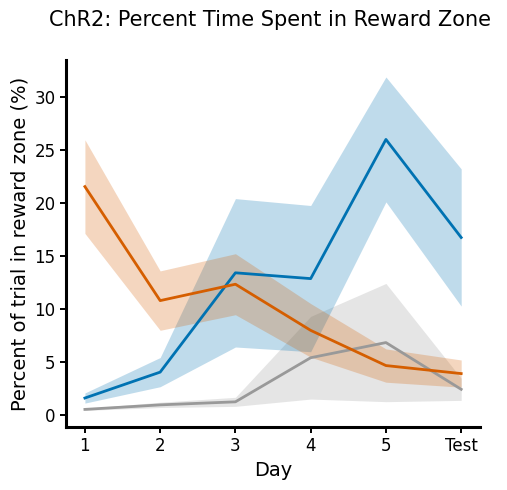

In [158]:
# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat  = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[trig_id]

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers, no individuals) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[trig_id]} (n={len(subs)})"
    )

ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

# journal-style axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent Time Spent in Reward Zone \n', fontsize=15, pad=8)

# small n text if you still want it
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Compute number of crossings

In [175]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: number of crossings into ANY trigger zone
metadata['n_crossings'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'n_crossings'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Build visit episodes for each trigger
    dfs = []
    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        if len(df_trigger_interaction) == 0:
            continue
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    # Number of crossings = number of visits to any trigger
    if len(dfs) == 0:
        n_crossings = 0
    else:
        df_all_triggers = pd.concat(dfs, ignore_index=True)
        # (sorting not required for counting, but harmless)
        # df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
        n_crossings = len(df_all_triggers)

    metadata.at[trial_id, 'n_crossings'] = n_crossings

 15%|█▌        | 712/4611 [00:07<00:35, 109.11it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1188/4611 [00:11<00:30, 112.37it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2617/4611 [00:23<00:11, 171.10it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:39<00:00, 117.02it/s]


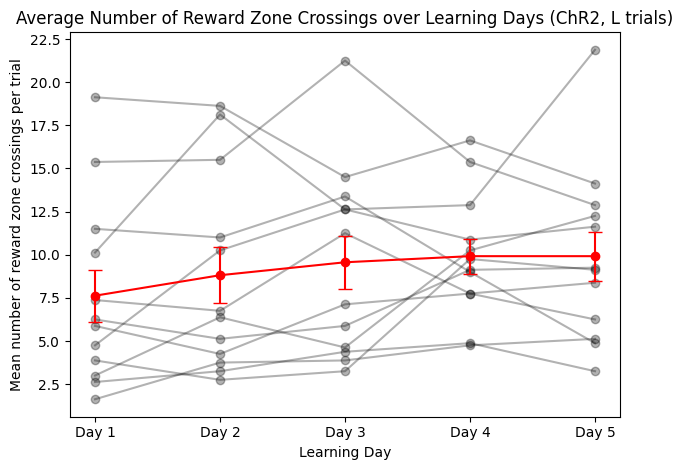

In [37]:
# number of crossings. Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean number of crossings per day for this animal
    mean_crossings_by_day = meta_sub.groupby('trial_type_day')['n_crossings'].mean()
    mean_crossings_by_day = mean_crossings_by_day.sort_index()

    # Expect 5 days; skip animals missing days
    if len(mean_crossings_by_day) != 5:
        continue

    performance_mat.append(mean_crossings_by_day.values)

    # Individual animal trace (thin black)
    plt.plot(range(5), mean_crossings_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM across animals
if len(performance_mat) > 0:
    performance_mat = np.vstack(performance_mat)
    mean_performance = np.nanmean(performance_mat, axis=0)
    sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

    plt.errorbar(
        range(5),
        mean_performance,
        yerr=sem_performance,
        fmt='-o',
        color='r',
        capsize=5
    )

plt.xlabel('Learning Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Average Number of Reward Zone Crossings over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 long animals plotted: 12
eYFP animals plotted: 5
ChR2 short animals plotted: 4


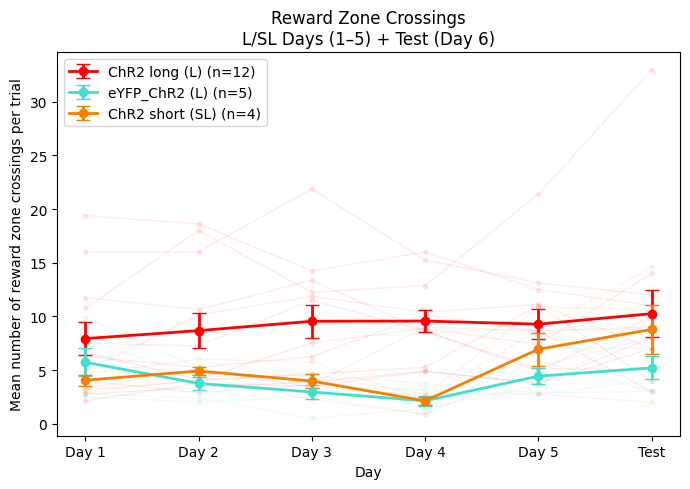

In [176]:
# number of crossings, ChR2 & eYFP_ChR2 & Short duration

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + day 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of n_crossings
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL'
    short_duration_val:
        None  -> ignore this column
        0 or 1 -> restrict to it
    """

    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Learning days = trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build vector [days 1–6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for 3 groups
# ------------------------------------------------------------

# Group 1: ChR2 long → L learning
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 → L learning
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short → SL learning
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted:", len(subs_ChR2_long))
print("eYFP animals plotted:", len(subs_eYFP))
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded single-animal lines
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot the 3 groups
plot_group(mat_ChR2_long, subs_ChR2_long, color='red',       label='ChR2 long (L)')
plot_group(mat_eYFP,      subs_eYFP,      color='turquoise', label='eYFP_ChR2 (L)')
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')


plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Reward Zone Crossings\nL/SL Days (1–5) + Test (Day 6)')
plt.xticks(
    ticks=np.arange(6),
    labels=['Day 1','Day 2','Day 3','Day 4','Day 5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

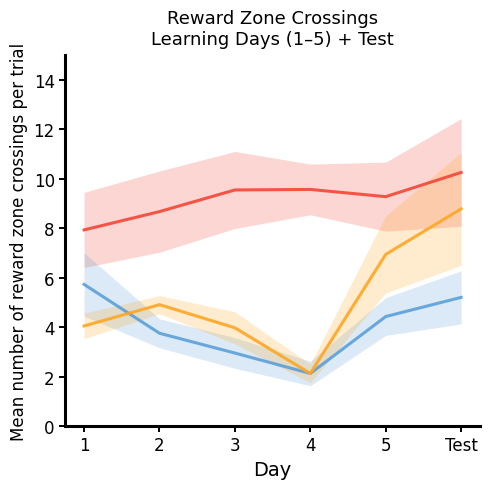

In [184]:
# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, no individual traces
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:          (n_animals x n_days) matrix of n_crossings
    subs:         list of animal IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'eYFP_ChR2', 'ChR2_short')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- plot all 3 groups using colour function ---
plot_group_shaded(
    mat_ChR2_long,
    subs_ChR2_long,
    genotype_key='ChR2',
    label='ChR2_long'
)

plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2'
)

plot_group_shaded(
    mat_ChR2_short,
    subs_ChR2_short,
    genotype_key='ChR2_short',
    label='ChR2_short'
)

# ------------------------------------------------------------
# Axes, labels, and style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean number of reward zone crossings per trial', fontsize=12)
plt.title('Reward Zone Crossings\nLearning Days (1–5) + Test', fontsize=13, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

#plt.legend(frameon=False)
plt.ylim(0,15)
plt.tight_layout()
plt.show()

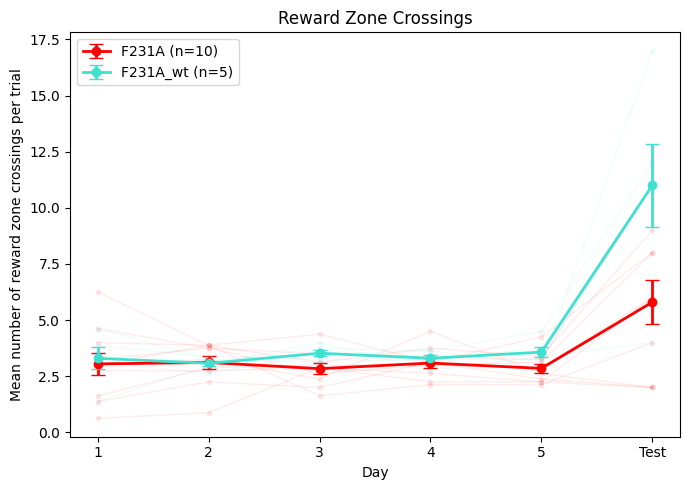

In [51]:
# number of crossings, F231a VS WT

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L','T'])) &
    (metadata['id'] != 'BQ')
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + day 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):

    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))


    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Learning days = trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build vector [days 1–6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for 3 groups
# ------------------------------------------------------------

# Group 1: ChR2 long → L learning
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='F231A',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 → L learning
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='F231A_wt',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded single-animal lines
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot the 3 groups
plot_group(mat_ChR2_long, subs_ChR2_long, color='red',       label='F231A')
plot_group(mat_eYFP,      subs_eYFP,      color='turquoise', label='F231A_wt')


plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Reward Zone Crossings')
plt.xticks(
    ticks=np.arange(6),
    labels=['1','2','3','4','5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2 long : 12
  eYFP      : 5


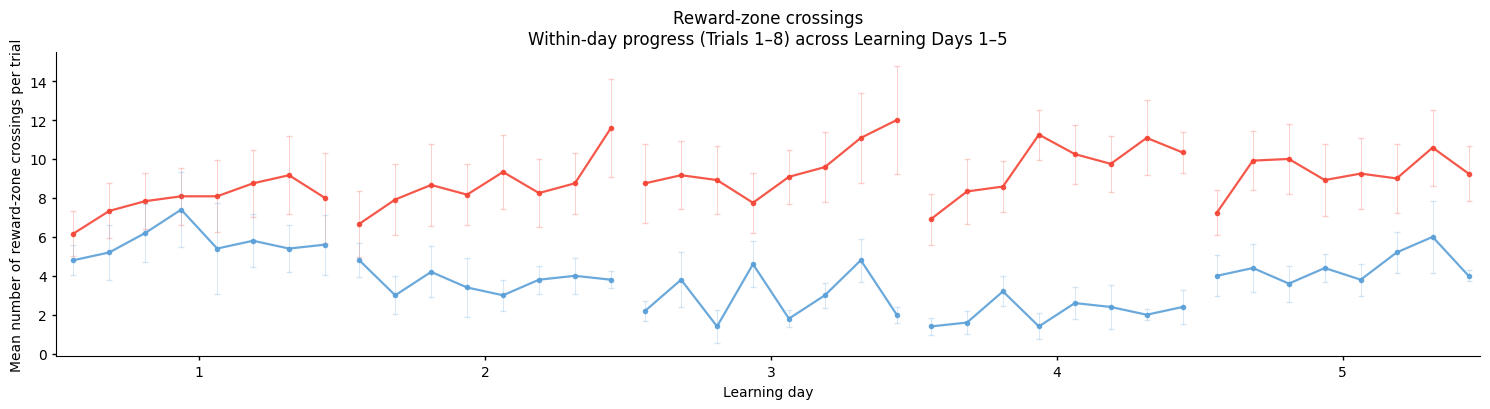

In [208]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: n_crossings (per trial)
# Groups are easy to toggle by commenting out blocks below.
# ============================================================

# ------------------------------------------------------------
# 1) Base filter (edit these lines to switch cohorts)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &   # optional global exclusion
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['n_crossings'].notna())        # <-- crossings metric
].copy()

days   = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) subject × trial matrix for a given day (allow missing trials)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['n_crossings'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: mean + faded SEM only (no individual traces)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean curve
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # faded SEM bars
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.25),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Define groups (COMMENT OUT whichever you don't want)
# ------------------------------------------------------------

# --- Group 1: ChR2 long (L, short_duration=0) ---
meta_ChR2_long = meta_L[
    (meta_L['genotype'] == 'ChR2') &
    # (meta_L['genotype'] == 'F231A') &
    (meta_L['trial_type'] == 'L') &
    (meta_L['short_duration'] == 0)
].copy()

# --- Group 2: ChR2 short (SL, short_duration=1) ---
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

# --- Group 3: eYFP_ChR2 controls (L, any short_duration) ---
meta_eYFP = meta_L[
    (meta_L['genotype'] == 'eYFP_ChR2') &
    # (meta_L['genotype'] == 'F231A_wt') &
    (meta_L['trial_type'] == 'L')
].copy()

# --- Optional extra group example: Hp (if you enable Hp above) ---
# meta_Hp = meta_L[
#      (meta_L['genotype'] == 'Hp') &
#      (meta_L['trial_type'] == 'L')
#  ].copy()

print("Animals included (n):")
print("  ChR2 long :", meta_ChR2_long['sub'].nunique())
# print("  ChR2 short:", meta_ChR2_short['sub'].nunique())
print("  eYFP      :", meta_eYFP['sub'].nunique())
# print("  Hp        :", meta_Hp['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(
    ax,
    meta_ChR2_long,
    color=get_genotype_color('ChR2'),
    alpha=0.9
)

# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     color=get_genotype_color('ChR2_short'),
#     alpha=1.0
# )

plot_within_day_curves(
    ax,
    meta_eYFP,
    color=get_genotype_color('eYFP_ChR2'),
    alpha=0.9
)

# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     color=get_genotype_color('Hp'),
#     alpha=0.9
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Mean number of reward-zone crossings per trial')

# day labels centered under each day's curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# reduce whitespace + ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Reward-zone crossings\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.tight_layout()
plt.show()

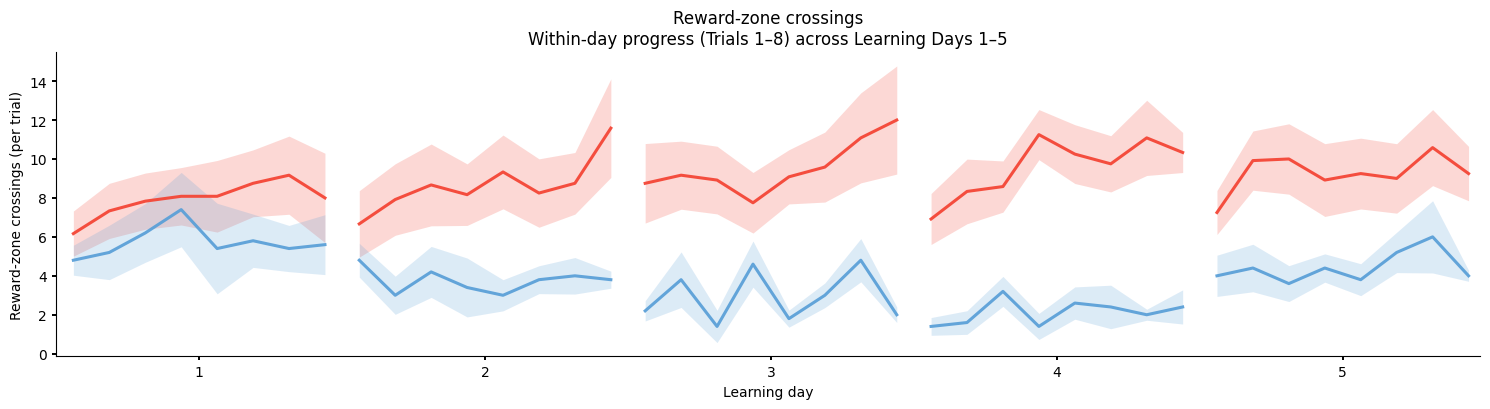

In [209]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: n_crossings (per trial)
# Groups toggle by commenting lines below.
# Style: shaded SEM, no individual traces, no markers.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Base filter (matches your original logic)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ','BP'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1,2,3,4,5])) &
    (metadata['n_crossings'].notna())
].copy()

days   = np.array([1,2,3,4,5])
trials = np.arange(1,9)

# ------------------------------------------------------------
# 2) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day','trial_num','trial_number','trial','trial_idx',
    'trial_index','trial_in_session','trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub','ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub','ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1,8)].copy()

# ------------------------------------------------------------
# 3) Build subject × trial_matrix for each day
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['n_crossings'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)
    return None if len(rows)==0 else np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper — shaded SEM, no individuals, no markers
# ------------------------------------------------------------
def plot_shaded(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 bins within day

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n,1))

        # shaded SEM
        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=color,
            alpha=min(alpha*0.22, 0.35),
            linewidth=0
        )

        # mean line
        ax.plot(
            x,
            mean_,
            '-',
            color=color,
            alpha=alpha,
            linewidth=2.2
        )

# ------------------------------------------------------------
# 5) Nature-style frame
# ------------------------------------------------------------
def style_nature(ax):
    for s in ['top','right']:
        ax.spines[s].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1.4)

# ------------------------------------------------------------
# 6) Groups (unchanged toggle logic)
# ------------------------------------------------------------

meta_ChR2_long = meta_L[
    (meta_L['genotype']=='ChR2') &
    (meta_L['trial_type']=='L') &
    (meta_L['short_duration']==0)
].copy()

# meta_ChR2_short = meta_L[
#     (meta_L['genotype']=='ChR2') &
#     (meta_L['trial_type']=='SL') &
#     (meta_L['short_duration']==1)
# ].copy()

meta_eYFP = meta_L[
    (meta_L['genotype']=='eYFP_ChR2') &
    (meta_L['trial_type']=='L')
].copy()

# meta_Hp = meta_L[
#     (meta_L['genotype']=='Hp') &
#     (meta_L['trial_type']=='L')
# ].copy()

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1,1, figsize=(15,4.2))

plot_shaded(ax, meta_ChR2_long, color=get_genotype_color('ChR2'), alpha=0.95)
# plot_shaded(ax, meta_ChR2_short, color=get_genotype_color('ChR2_short'), alpha=1.0)
plot_shaded(ax, meta_eYFP,      color=get_genotype_color('eYFP_ChR2'), alpha=0.95)
# plot_shaded(ax, meta_Hp,       color=get_genotype_color('Hp'), alpha=0.95)

ax.set_xlabel('Learning day')
ax.set_ylabel('Reward-zone crossings (per trial)')

ax.set_xticks(days + 0.5)
ax.set_xticklabels(days.astype(str))
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Reward-zone crossings\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.tight_layout()
plt.show()

ChR2 (short_duration=0) animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


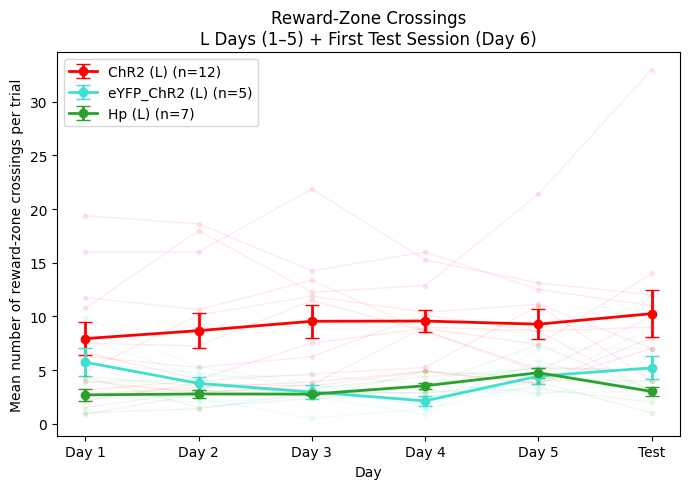

In [185]:
# number of crossings, ChR2 & eYFP_ChR2 & Hp

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, 3 genotypes, L/T
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_df, genotype, short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) n_crossings per day
      - subjects: list of subject IDs

    Learning trials are 'L', test is first 'T' session after last L session.
    short_duration_val:
        None -> no filter
        0 or 1 -> restrict to that value
    """

    # subset by genotype & trial type
    mask = (meta_df['genotype'] == genotype) & \
           (meta_df['trial_type'].isin(['L', 'T']))

    if short_duration_val is not None:
        mask &= (meta_df['short_duration'] == short_duration_val)

    meta_g = meta_df[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # learning trials (L) for this animal
        mL = ms[ms['trial_type'] == 'L']
        if len(mL) == 0:
            continue

        # assign L days 1–5 from trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last L session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per plot_day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
# ------------------------------------------------------------

# Group 1: ChR2 long (short_duration == 0)
mat_ChR2, subs_ChR2 = build_group_matrix(
    meta_LT,
    genotype='ChR2',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 (any short_duration)
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_LT,
    genotype='eYFP_ChR2',
    short_duration_val=None,
    require_complete=True
)

# Group 3: Hp (any short_duration)
mat_Hp, subs_Hp = build_group_matrix(
    meta_LT,
    genotype='Hp',
    short_duration_val=None,
    require_complete=True
)

print("ChR2 (short_duration=0) animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
print("Hp animals plotted:", len(subs_Hp))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded individual traces
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot groups with your colour scheme
plot_group(mat_ChR2, subs_ChR2, color='red',      label='ChR2 (L)')
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')
plot_group(mat_Hp,   subs_Hp,   color='#2ca02c',  label='Hp (L)')

plt.xlabel('Day')
plt.ylabel('Mean number of reward-zone crossings per trial')
plt.title('Reward-Zone Crossings\nL Days (1–5) + First Test Session (Day 6)')
plt.xticks(
    ticks=np.arange(6),
    labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

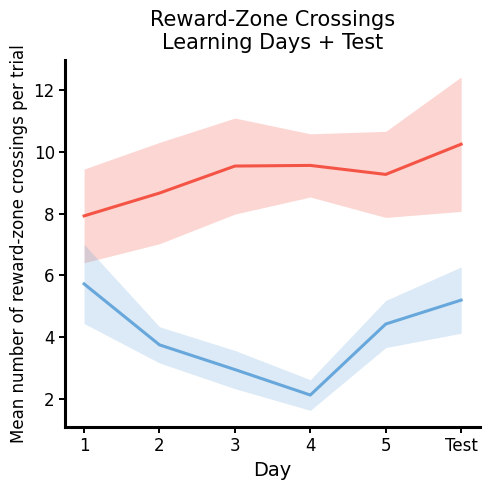

In [189]:
# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, no individual traces
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:          (n_animals x n_days) matrix of n_crossings
    subs:         list of animal IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'eYFP_ChR2', 'Hp')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- plot all 3 groups with your colour function ---
plot_group_shaded(mat_ChR2, subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2 (L)')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2 (L)')

#plot_group_shaded(mat_Hp, subs_Hp,
#                  genotype_key='Hp',
#                  label='Hp (L)')

# ------------------------------------------------------------
# Axes, labels, style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean number of reward-zone crossings per trial', fontsize=12)
plt.title('Reward-Zone Crossings\nLearning Days + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ArchT animals plotted:       6
eYFP_ArchT animals plotted: 6


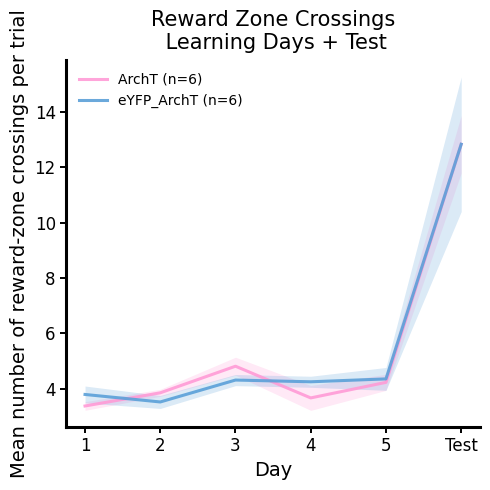

In [194]:
# number of crossings, ArchT & eYFP_ArchT

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, ArchT / eYFP_ArchT, L/T
# ------------------------------------------------------------
meta_LT_Arch = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix_arch(meta_df, genotype, short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) n_crossings per day
      - subjects: list of subject IDs

    Learning trials are 'L', test is first 'T' session after last L session.
    short_duration_val:
        None -> no filter
        0 or 1 -> restrict to that value
    """

    mask = (meta_df['genotype'] == genotype) & \
           (meta_df['trial_type'].isin(['L', 'T']))

    if short_duration_val is not None:
        mask &= (meta_df['short_duration'] == short_duration_val)

    meta_g = meta_df[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials (L) for this animal
        mL = ms[ms['trial_type'] == 'L']
        if len(mL) == 0:
            continue

        # assign L days 1–5 from trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last L session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per plot_day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for ArchT and eYFP_ArchT
# ------------------------------------------------------------
mat_ArchT,      subs_ArchT      = build_group_matrix_arch(meta_LT_Arch, 'ArchT',
                                                          short_duration_val=None,
                                                          require_complete=True)
mat_eYFP_ArchT, subs_eYFP_ArchT = build_group_matrix_arch(meta_LT_Arch, 'eYFP_ArchT',
                                                          short_duration_val=None,
                                                          require_complete=True)

print("ArchT animals plotted:      ", len(subs_ArchT))
print("eYFP_ArchT animals plotted:", len(subs_eYFP_ArchT))


# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, no individual traces
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:          (n_animals x n_days) matrix of n_crossings
    subs:         list of animal IDs
    genotype_key: key for get_genotype_color (e.g. 'ArchT', 'eYFP_ArchT')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# --- plot both groups with your colour function ---
plot_group_shaded(mat_ArchT,      subs_ArchT,
                  genotype_key='ArchT',
                  label='ArchT')

plot_group_shaded(mat_eYFP_ArchT, subs_eYFP_ArchT,
                  genotype_key='eYFP_ArchT',
                  label='eYFP_ArchT')


# ------------------------------------------------------------
# Axes, labels, style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean number of reward-zone crossings per trial', fontsize=14)
plt.title('Reward Zone Crossings\n Learning Days + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Compute the number of crossings 

In [195]:
#COMPUTE NUMBER OF CROSSINGS (PER TRIGGER) -----

import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# Any-trigger version (kept for consistency)
metadata['n_crossings'] = np.nan

R_TRIGGER = (10/1.2)

cross_rows = []  # per-trigger rows

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'n_crossings'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    dfs = []
    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        if len(df_trigger_interaction) == 0:
            continue
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    # ANY trigger crossings (your original logic)
    if len(dfs) == 0:
        n_crossings = 0
        metadata.at[trial_id, 'n_crossings'] = 0
    else:
        df_all_triggers = pd.concat(dfs, ignore_index=True)
        n_crossings = len(df_all_triggers)
        metadata.at[trial_id, 'n_crossings'] = n_crossings

    # ---- PER TRIGGER: SAME LOGIC, but split ----
    for trig_id in range(1, len(triggerLoc) + 1):
        if len(dfs) == 0:
            n_trig = 0
        else:
            df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
            n_trig = len(df_t)

        cross_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'n_crossings_trig': n_trig
        })

# Long-format per-trigger table + metadata
df_cross = pd.DataFrame(cross_rows)
meta_cross = df_cross.merge(metadata, left_on='trial_id', right_index=True, how='left')

 15%|█▌        | 711/4611 [00:07<00:36, 106.93it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1184/4611 [00:11<00:30, 112.68it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2610/4611 [00:23<00:12, 164.64it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:39<00:00, 116.32it/s]


Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


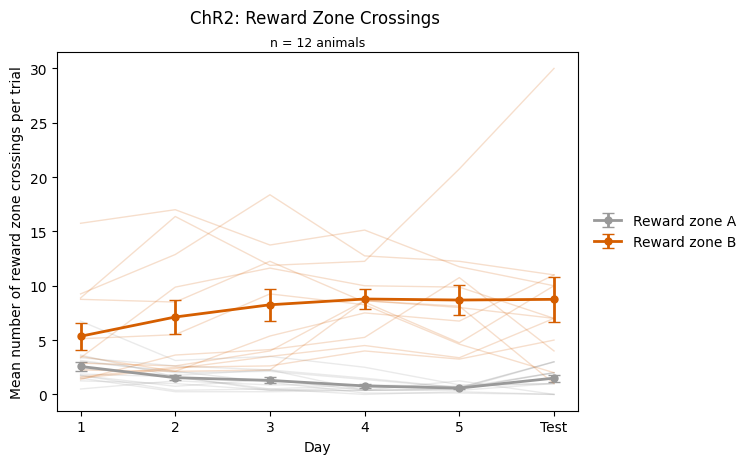

In [196]:
# ----- FILTER: ChR2, L/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_cross[
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'].isin(['L', 'T']))
].copy()

# L days
mt['plot_day'] = np.nan
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep L days 1–5 only
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T after last L as day 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (CROSSINGS) -----

def build_zone_matrix_cross(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['n_crossings_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}

for zid in zone_ids:
    mat, subs = build_zone_matrix_cross(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: NUMBER OF CROSSINGS (ChR2, ZONE A/B) -----

plt.figure(figsize=(9, 5))  # wider
x_vals = plot_days - 1

# requested: Reward zone A = grey
colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # faded individuals (no ID labels)
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    

    # mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')

plt.title('ChR2: Reward Zone Crossings \n', fontsize=12)
ax.text(
    0.5, 1.01,
    f'n = {n_animals} animals',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

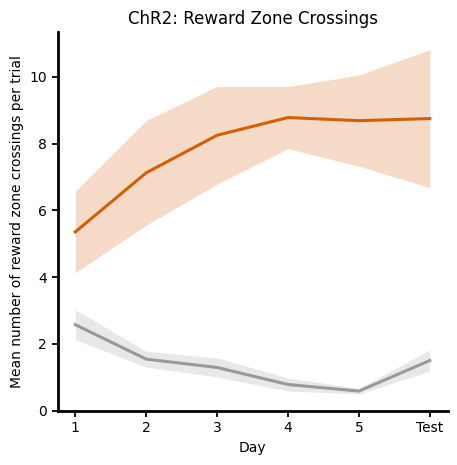

In [201]:
# ----- PLOT: NUMBER OF CROSSINGS (ChR2, ZONE A/B) -----

plt.figure(figsize=(5.5, 5))  # wider
x_vals = plot_days - 1

# colours for zones (these are already your "style" colours)
colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    col = colors[zid]

    # --- shaded SEM band (faded) ---
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.22,
        linewidth=0
    )

    # --- mean line (no individual traces, no markers) ---
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2.2,
        label=f'{labels[zid]} (n={len(subs)})'
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')

plt.title('ChR2: Reward Zone Crossings', fontsize=12)
#ax.text(
#    0.5, 1.02,
#    f'Overall n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    va='bottom',
#    fontsize=9
#)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# journal-style axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.3)

#plt.legend(
#    loc='center left',
#    bbox_to_anchor=(1.02, 0.5),
#    borderaxespad=0.,
#    frameon=False
#)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


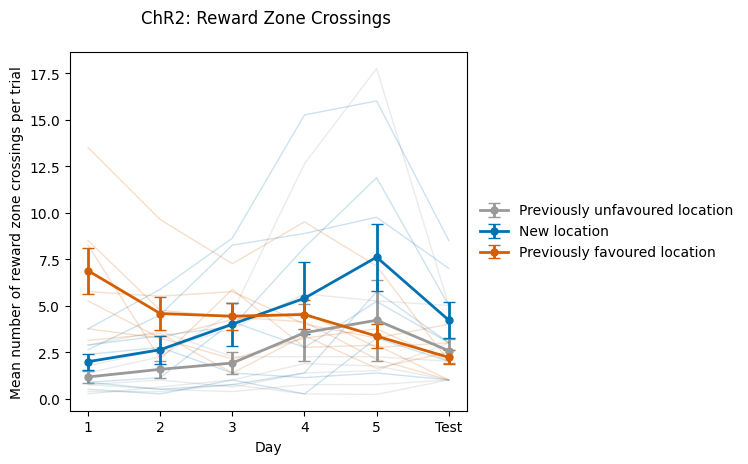

In [202]:
# ----- FILTER: ChR2, RL/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import matplotlib.pyplot as plt

mt = meta_cross[
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'].isin(['RL', 'T']))
].copy()

# RL days
mt['plot_day'] = np.nan
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep RL days 1–5 only
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T after RL as day 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]

# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER (CROSSINGS) -----

def build_trigger_matrix_cross(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['n_crossings_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


mat_trig = {}
subs_trig = {}

for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix_cross(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", subs)
    print("-" * 50)

    # ----- PLOT: NUMBER OF CROSSINGS (ChR2, PER TRIGGER) -----

plt.figure(figsize=(9, 5))  # wider

x_vals = plot_days - 1

# Same “paper” colors
colors = {
    1: '#999999',  # previously unfavoured
    2: '#0072B2',  # new location
    3: '#D55E00',  # previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # faded individuals
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')

plt.title('ChR2: Reward Zone Crossings \n', fontsize=12)


plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

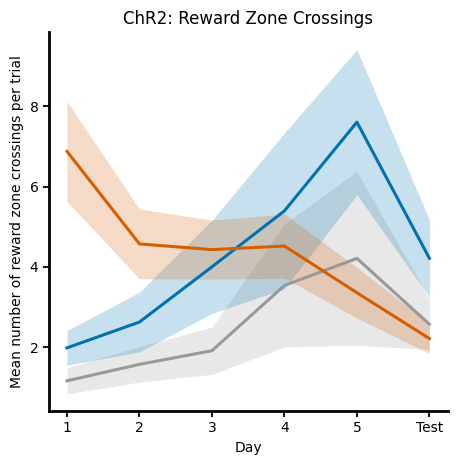

In [206]:
# ----- PLOT: NUMBER OF CROSSINGS (ChR2, PER TRIGGER) -----

plt.figure(figsize=(5.5, 5))  # wider

x_vals = plot_days - 1  # 0..5

# Same “paper” colors
colors = {
    1: '#999999',  # previously unfavoured
    2: '#0072B2',  # new location
    3: '#D55E00',  # previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    col = colors[trig_id]

    # --- shaded SEM band (faded) ---
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.22,
        linewidth=0
    )

    # --- mean line (no individual traces, no markers) ---
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2.2,
        label=f'{labels[trig_id]} (n={len(subs)})'
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')

plt.title('ChR2: Reward Zone Crossings', fontsize=12)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# journal-style axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.3)

#plt.legend(
#    loc='center left',
#    bbox_to_anchor=(1.02, 0.5),
#    borderaxespad=0.,
#    frameon=False
#)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

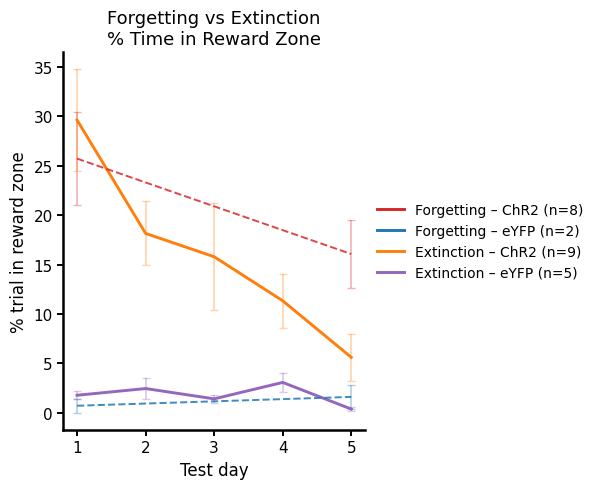

In [251]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Restrict to TEST trials, desired genotypes, and NOT short_duration ----
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1)
].copy()

max_day = 5
day_values = np.arange(1, max_day + 1)


# ---- 2. Build subject × test-day matrix ----
def build_subject_matrix(meta_group):
    performance_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        m = meta_group[meta_group['sub'] == sub]
        mean_d = m.groupby('trial_type_day')['pct_time_in_trigger'].mean()

        vec = np.full(max_day, np.nan)
        for i, d in enumerate(day_values):
            if d in mean_d.index:
                vec[i] = mean_d.loc[d]

        # skip animals with no data at all
        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects


def mean_and_sem(mat):
    """
    Robust mean/SEM:
    - returns NaN for days where all animals are NaN
    - avoids RuntimeWarnings from nanmean / nanstd
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem  = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)

    return mean, sem


# ---- 3. Split by genotype × test_type ----
meta_ChR2 = meta_T[meta_T['genotype'] == 'ChR2']
meta_YFP  = meta_T[meta_T['genotype'] == 'eYFP_ChR2']

perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(meta_ChR2[meta_ChR2['test_type'] == 'forgetting'])
perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(meta_ChR2[meta_ChR2['test_type'] == 'extinction'])

perf_f_YFP, subs_f_YFP   = build_subject_matrix(meta_YFP[meta_YFP['test_type'] == 'forgetting'])
perf_e_YFP, subs_e_YFP   = build_subject_matrix(meta_YFP[meta_YFP['test_type'] == 'extinction'])


# ---- 4. Plot  ----
plt.figure(figsize=(7.5, 5))

col_f_ChR2 = 'tab:red'
col_e_ChR2 = 'tab:orange'
col_f_YFP  = 'tab:blue'
col_e_YFP  = 'tab:purple'


def plot_group(mat, color, label):
    if mat is None or mat.size == 0:
        return
    mean, sem = mean_and_sem(mat)
    if mean is None:
        return

    # line for mean
    plt.plot(
        day_values, mean,
        '-', color=color,
        linewidth=2.1,
        label=label
    )

    # faded SEM
    plt.errorbar(
        day_values, mean, yerr=sem,
        fmt='none',
        ecolor=color,
        alpha=0.35,       # more faded
        elinewidth=1.2,
        capsize=3
    )


def plot_forgetting_trend(mat, color):
    if mat is None or mat.size == 0:
        return
    mean, _ = mean_and_sem(mat)
    if mean is None:
        return
    if np.isnan(mean[0]) or np.isnan(mean[-1]):
        return
    plt.plot(
        [day_values[0], day_values[-1]],
        [mean[0], mean[-1]],
        '--',
        color=color,
        alpha=0.85,
        linewidth=1.4
    )


# forgetting
plot_group(perf_f_ChR2, col_f_ChR2, f'Forgetting – ChR2 (n={len(subs_f_ChR2)})')
plot_group(perf_f_YFP,  col_f_YFP,  f'Forgetting – eYFP (n={len(subs_f_YFP)})')

# extinction
plot_group(perf_e_ChR2, col_e_ChR2, f'Extinction – ChR2 (n={len(subs_e_ChR2)})')
plot_group(perf_e_YFP,  col_e_YFP,  f'Extinction – eYFP (n={len(subs_e_YFP)})')

# dashed forgetting trends
plot_forgetting_trend(perf_f_ChR2, col_f_ChR2)
plot_forgetting_trend(perf_f_YFP,  col_f_YFP)

# ---- Axes: NN style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('% trial in reward zone', fontsize=12)
plt.xticks(day_values, [str(d) for d in day_values], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Forgetting vs Extinction\n% Time in Reward Zone', fontsize=13, pad=6)

# ---- Legend to the right ----
plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

Per-animal Day 5 test values:
     test_type  animal  pct_time_in_trigger
0   extinction       6             3.107028
1   extinction       7             4.803077
2   extinction       8            19.859134
3   extinction      10             1.489747
4   extinction      11             3.370552
5   extinction      16             3.575044
6   extinction      18             3.091851
7   forgetting       6            15.433859
8   forgetting       7            14.348776
9   forgetting       9            35.532230
10  forgetting      10            22.356585
11  forgetting      11             7.716140
12  forgetting      12            16.890772
13  forgetting      16             3.736940
14  forgetting      18            12.542359

Forgetting (ChR2) – Day 5, n = 8
Extinction (ChR2) – Day 5, n = 7
Mann–Whitney U (Day 5 — Forgetting vs Extinction, ChR2) p = 0.014


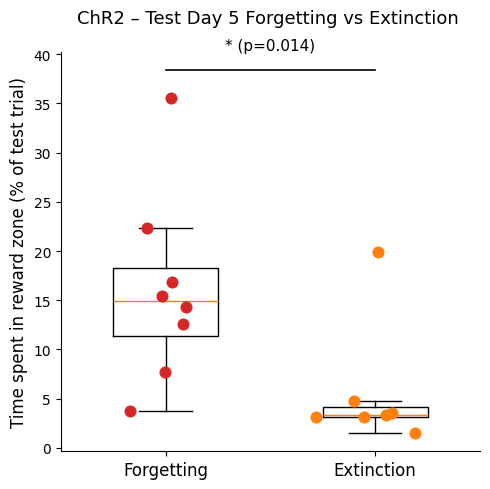

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials for ChR2, Forgetting vs Extinction, Day 5 only
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'] == 'T') &
    (metadata['short_duration'] != 1) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['test_type'].isin(['forgetting', 'extinction'])) &
    (metadata['trial_type_day'] == 5)      # ✅ Day 5 test only
].copy()

# Rename for convenience
meta_T['animal'] = meta_T['sub']

# ------------------------------------------------------------
# 2) Collapse to one point per animal per test_type (mean over T trials on Day 5)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['test_type', 'animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print("Per-animal Day 5 test values:")
print(meta_animal)

# Extract arrays
vals_f = meta_animal.loc[meta_animal['test_type'] == 'forgetting',
                         'pct_time_in_trigger'].values
vals_e = meta_animal.loc[meta_animal['test_type'] == 'extinction',
                         'pct_time_in_trigger'].values

print(f"\nForgetting (ChR2) – Day 5, n = {len(vals_f)}")
print(f"Extinction (ChR2) – Day 5, n = {len(vals_e)}")

# If one group has no animals, warn and stop
if (len(vals_f) == 0) or (len(vals_e) == 0):
    print("⚠️ One of the groups has no Day 5 test animals. "
          "Check metadata['test_type'] and trial_type_day==5.")
else:
    # --------------------------------------------------------
    # 3) Mann–Whitney U test (Forgetting vs Extinction)
    # --------------------------------------------------------
    stat, p = mannwhitneyu(vals_f, vals_e, alternative='two-sided')
    print(f"Mann–Whitney U (Day 5 — Forgetting vs Extinction, ChR2) p = {p:.3g}")

    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 0.05: return "*"
        return "n.s."

    stars = p_to_stars(p)

    # --------------------------------------------------------
    # 4) Prepare data & colors for boxplot
    # --------------------------------------------------------
    groups = ['Forgetting', 'Extinction']
    data   = [vals_f, vals_e]
    colors = ['tab:red', 'tab:orange']   # or swap to your own palette

    # --------------------------------------------------------
    # 5) Plot boxplot + jittered dots
    # --------------------------------------------------------
    plt.figure(figsize=(5, 5))

    bp = plt.boxplot(
        data,
        positions=np.arange(len(groups)),
        widths=0.5,
        patch_artist=False,   # outline only
        showfliers=False      # we show all animals as scatter instead
    )

    # Jittered animal points
    for i, vals in enumerate(data):
        n = len(vals)
        if n == 0:
            continue
        jitter = 0.12
        x = np.random.normal(i, jitter, size=n)

        plt.scatter(
            x, vals,
            s=65,
            color=colors[i],
            linewidth=0.6,
            zorder=3
        )

    # --------------------------------------------------------
    # 6) Significance bar between the two groups
    # --------------------------------------------------------
    ymax = np.nanmax(np.concatenate([vals_f, vals_e]))
    y_line = ymax * 1.08
    y_star = ymax * 1.13

    # horizontal bar from x=0 to x=1
    plt.plot(
        [0, 0, 1, 1],
        [y_line, y_line, y_line, y_line],
        color='black',
        linewidth=1.2
    )

    plt.text(
        0.5, y_star,
        f"{stars} (p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=11
    )

    # --------------------------------------------------------
    # 7) Axes / labels / style
    # --------------------------------------------------------
    plt.xticks(np.arange(len(groups)), groups, fontsize=12)
    plt.ylabel('Time spent in reward zone (% of test trial)', fontsize=12)
    plt.xlabel('')
    plt.title('ChR2 – Test Day 5 Forgetting vs Extinction \n', fontsize=13)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

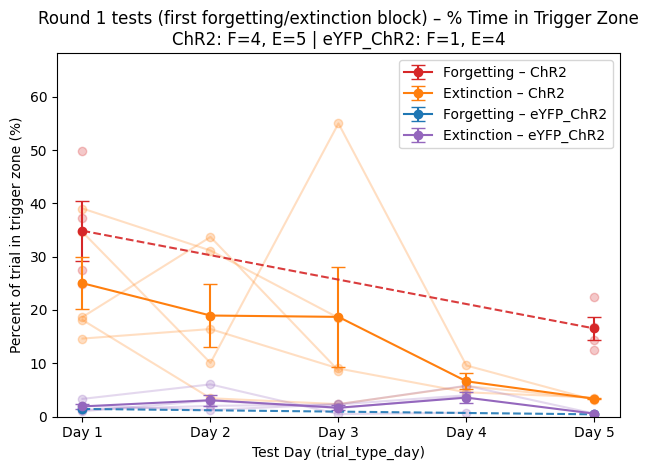

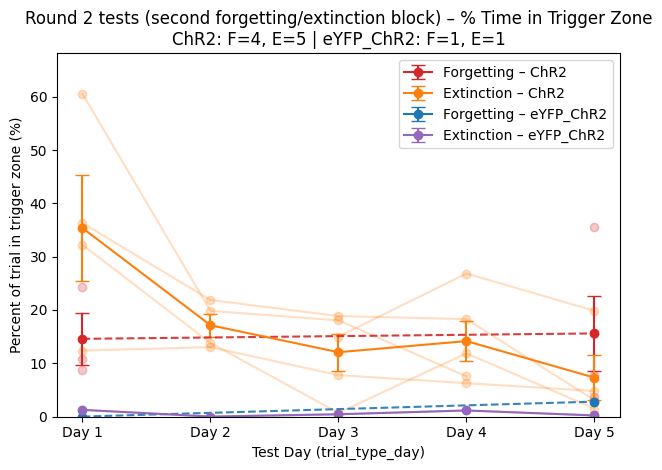

In [ ]:

# ============================================================
# 1. Filter metadata to test trials & assign test_round from test_order
# ============================================================

# Keep only test trials, the two genotypes, and non-short-duration
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1)
].copy()

# Make sure test_order is string
meta_T['test_order'] = meta_T['test_order'].astype(str)

# Initialise test_round
meta_T['test_round'] = np.nan  # will be 1 or 2

# Rules:
# ef: extinction first, forgetting second
# fe: forgetting first, extinction second
# e:  only extinction → all extinction = round 1
# ee: two extinction rounds → split by day into first half / second half
# ff: two forgetting rounds → same as above
for sub in meta_T['sub'].unique():
    sub_mask = (meta_T['sub'] == sub)
    sub_rows = meta_T[sub_mask].sort_values('trial_type_day')

    if len(sub_rows) == 0:
        continue

    order = sub_rows['test_order'].iloc[0]

    # ef: extinction first, forgetting second
    if order == 'ef':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 2

    # fe: forgetting first, extinction second
    elif order == 'fe':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 2

    # e: only extinction → all extinction trials are round 1
    elif order == 'e':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1

    # ee: two extinction rounds → split by day into first half / second half
    elif order == 'ee':
        e_rows = sub_rows[sub_rows['test_type'] == 'extinction'].sort_values('trial_type_day')
        idx = e_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))  # first ~half = round 1
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # ff: two forgetting rounds → split by day into first half / second half
    elif order == 'ff':
        f_rows = sub_rows[sub_rows['test_type'] == 'forgetting'].sort_values('trial_type_day')
        idx = f_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # else: unknown test_order → leave as NaN (ignored later)

max_day = 5
day_values = np.arange(1, max_day + 1)  # [1..5]


# ============================================================
# 2. Helper functions
# ============================================================

def build_subject_matrix(meta_group):
    """
    For a given subset (e.g. ChR2 + forgetting + round1),
    return:
      - performance_mat: (n_subjects x max_day) array with NaNs for missing days
      - subjects_used: list of subject IDs included

    Skips subjects that only have day 1 in this subset.
    """
    performance_mat = []
    subjects_used = []

    for sub in meta_group['sub'].unique():
        meta_sub = meta_group[meta_group['sub'] == sub]

        if len(meta_sub) == 0:
            continue

        # Mean % time in trigger zone per test day for this subject
        mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
        days_present = np.array(sorted(mean_pct_by_day.index.values))

        # Exclude subjects with only day 1 in this condition
        if (len(days_present) == 1) and (days_present[0] == 1):
            continue

        subj_vec = np.full(max_day, np.nan)
        for i, day in enumerate(day_values):
            if day in mean_pct_by_day.index:
                subj_vec[i] = mean_pct_by_day.loc[day]

        if np.isnan(subj_vec).all():
            continue

        performance_mat.append(subj_vec)
        subjects_used.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects_used


def mean_and_sem(mat):
    """Mean ± SEM across subjects, per day, handling all-NaN columns."""
    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
    return mean, sem


def plot_round(meta_T_full, round_num, title_prefix, y_limits=None):
    """Make a plot for test round 1 or 2."""
    meta_round = meta_T_full[meta_T_full['test_round'] == round_num].copy()
    if len(meta_round) == 0:
        print(f'No data for test_round {round_num}')
        return

    # split by genotype
    meta_ChR2 = meta_round[meta_round['genotype'] == 'ChR2']
    meta_eYFP = meta_round[meta_round['genotype'] == 'eYFP_ChR2']

    # build matrices for genotype × test_type
    perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'forgetting'])
    perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'extinction'])

    perf_f_YFP, subs_f_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'forgetting'])
    perf_e_YFP, subs_e_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'extinction'])

    # colors
    col_f_ChR2 = 'tab:red'       # soft red
    col_f_YFP = 'tab:blue'       # blue
    col_e_ChR2 = 'tab:orange'    # orange
    col_e_YFP = 'tab:purple'     # purple

    plt.figure()

    # ----- individual traces -----
    if perf_f_ChR2 is not None:
        for i in range(perf_f_ChR2.shape[0]):
            plt.plot(day_values, perf_f_ChR2[i, :],
                     '-o', color=col_f_ChR2, alpha=0.25, label='_nolegend_')

    if perf_e_ChR2 is not None:
        for i in range(perf_e_ChR2.shape[0]):
            plt.plot(day_values, perf_e_ChR2[i, :],
                     '-o', color=col_e_ChR2, alpha=0.25, label='_nolegend_')

    if perf_f_YFP is not None:
        for i in range(perf_f_YFP.shape[0]):
            plt.plot(day_values, perf_f_YFP[i, :],
                     '-o', color=col_f_YFP, alpha=0.25, label='_nolegend_')

    if perf_e_YFP is not None:
        for i in range(perf_e_YFP.shape[0]):
            plt.plot(day_values, perf_e_YFP[i, :],
                     '-o', color=col_e_YFP, alpha=0.25, label='_nolegend_')

    # ----- group means ± SEM -----
    mean_f_ChR2 = mean_f_YFP = None

    if perf_f_ChR2 is not None:
        mean_f_ChR2, sem = mean_and_sem(perf_f_ChR2)
        plt.errorbar(day_values, mean_f_ChR2, yerr=sem,
                     fmt='-o', color=col_f_ChR2, capsize=5,
                     label='Forgetting – ChR2')

    if perf_e_ChR2 is not None:
        mean, sem = mean_and_sem(perf_e_ChR2)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_ChR2, capsize=5,
                     label='Extinction – ChR2')

    if perf_f_YFP is not None:
        mean_f_YFP, sem = mean_and_sem(perf_f_YFP)
        plt.errorbar(day_values, mean_f_YFP, yerr=sem,
                     fmt='-o', color=col_f_YFP, capsize=5,
                     label='Forgetting – eYFP_ChR2')

    if perf_e_YFP is not None:
        mean, sem = mean_and_sem(perf_e_YFP)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_YFP, capsize=5,
                     label='Extinction – eYFP_ChR2')

    # dashed Day1–Day5 for forgetting group means (ChR2 & eYFP)
    if mean_f_ChR2 is not None and not np.isnan(mean_f_ChR2[0]) and not np.isnan(mean_f_ChR2[4]):
        plt.plot([1, 5], [mean_f_ChR2[0], mean_f_ChR2[4]],
                 '--', color=col_f_ChR2, alpha=0.9)

    if mean_f_YFP is not None and not np.isnan(mean_f_YFP[0]) and not np.isnan(mean_f_YFP[4]):
        plt.plot([1, 5], [mean_f_YFP[0], mean_f_YFP[4]],
                 '--', color=col_f_YFP, alpha=0.9)

    # sample sizes
    n_f_ChR2 = len(subs_f_ChR2)
    n_e_ChR2 = len(subs_e_ChR2)
    n_f_YFP = len(subs_f_YFP)
    n_e_YFP = len(subs_e_YFP)

    title_str = (
        f'{title_prefix} – % Time in Trigger Zone\n'
        f'ChR2: F={n_f_ChR2}, E={n_e_ChR2} | '
        f'eYFP_ChR2: F={n_f_YFP}, E={n_e_YFP}'
    )

    plt.title(title_str)
    plt.xlabel('Test Day (trial_type_day)')
    plt.ylabel('Percent of trial in trigger zone (%)')
    plt.xticks(day_values, [f'Day {d}' for d in day_values])
    plt.legend()

    # apply shared y-limits if provided
    if y_limits is not None:
        plt.ylim(y_limits)

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Compute shared y-axis limits across ALL test trials
# ============================================================

valid_vals = meta_T['pct_time_in_trigger'].values
valid_vals = valid_vals[~np.isnan(valid_vals)]

if len(valid_vals) > 0:
    y_min = 0
    y_max = 62
    #y_max = np.nanmax(valid_vals)
    y_limits = (y_min, y_max * 1.1)  # little headroom
else:
    y_limits = None  # fallback


# ============================================================
# 4. Make the two figures: round 1 and round 2 (shared y-axis)
# ============================================================

plot_round(
    meta_T,
    round_num=1,
    title_prefix='Round 1 tests (first forgetting/extinction block)',
    y_limits=y_limits
)

plot_round(
    meta_T,
    round_num=2,
    title_prefix='Round 2 tests (second forgetting/extinction block)',
    y_limits=y_limits
)

In [ ]:

cheeseboardMap = util.load_cheeseboard_map()
metadata = util.load_metadata()

# Create a column for minimum time to well in the metadata
metadata['min_time_to_well'] = np.nan

for idx in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[idx])
    position = dl.get_data('position')
    if position is None:
        continue
    x_loc = position['smooth_trans_x'].values
    y_loc = position['smooth_trans_y'].values
    in_roi = position['inside_roi'].values
    x_loc[x_loc == -1] = np.nan
    y_loc[y_loc == -1] = np.nan



    # Get the trigger locations
    well_coords = []
    for i in range(len(triggerLoc)):
        cheeseboardMap_loc = cheeseboardMap[(cheeseboardMap['well_row'] == triggerLoc['well_row'].values[i]) & (cheeseboardMap['well_col'] == triggerLoc['well_col'].values[i])]
        well_coords.append((cheeseboardMap_loc['trans_X'].values[0], cheeseboardMap_loc['trans_Y'].values[0]))


    well_behav_metrics = compute_well_behav_metrics_all(x_loc, y_loc, well_coords)
    if np.nansum(well_behav_metrics['fraction_time_in_well']) == 0:
        continue
    min_time_to_well = np.nanmin(well_behav_metrics['time_to_arrive_zone'].values)
    metadata.at[idx, 'min_time_to_well'] = min_time_to_well

In [ ]:
metadata_L = metadata[metadata['trial_type'] == 'L']#.reset_index(drop=True)